# Charged test particles in forced 2D RMHD turbulence

Boris-pushed test particles co-stepped with taranis's RMHD solver
(`plans/TESTPART_PLAN.md` phases A3/A3b). The particles see the solver's own fields and
never back-react, so many ensembles differing only in their gyrofrequency, their initial
distribution, the RMHD amplitude they are interpreted at, or *which pieces of the field
they are allowed to see* ride the same turbulence at once.

With taranis's conventions ($\mathbf{u} = \hat z\times\nabla\varphi$,
$\mathbf{b}_\perp = \hat z\times\nabla\psi$, $\Phi = B_0\varphi$, $A_z = -\psi$;
`docs/numerics.md` "Test particles"):

$$\mathbf{B} = B_0\hat z + \hat z\times\nabla\psi,\qquad
  \mathbf{E}_\perp = -B_0\nabla\varphi,\qquad
  E_z = +\frac{\partial\psi}{\partial t} = -\{\varphi,\psi\} + L_\psi\psi + f_\psi .$$

Three things about this run are different from a naive test-particle setup, and all three
follow Xia, Perez, Chandran & Quataert (2013, ApJ 776, 90):

1. **$B_0$ is the RMHD amplitude parameter, $B_0 = 1/\varepsilon$** (derived in
   `docs/numerics.md`, "E∥ projection and the amplitude parameter"). Nondimensionalizing the
   real particle equation in RMHD units makes the code's push identical to the physical one
   with $\hat\Omega = (q/m)B_0$ and $B_0 = 1/\varepsilon$, so $B_0 = 1$ means
   $\delta B/B_0\sim1$ — an amplitude no RMHD ordering supports (Xia et al. cap their runs at
   $\delta B_{rms}/B_0\le0.47$ and flag even that). Production here is $B_0 = 10$ with $q/m$
   scaled by $1/B_0$, which leaves $\rho$, $\Omega\,dt$ and $\xi$ untouched and puts
   $\beta_i = v_{th}^2/B_0^2 = 0.01$. A **contrast cohort at $B_0 = 1$**, same $\Omega$,
   rides alongside: that is the $\varepsilon = 1$ vs $\varepsilon = 0.1$ comparison at
   identical $\rho$ and $\xi$.
2. **The numerical $E_\parallel$ is projected out.** On the grid the ideal fields are
   exactly orthogonal, but `interp.gather` interpolates $\mathbf{E}$ and $\mathbf{B}$
   independently, so the *sampled* $\bar{\mathbf E}\cdot\bar{\mathbf B}\ne0$ — a parallel
   electric field of purely numerical origin (measured below at $1.6\times10^{-3}$ of
   $|E||B|$). Every production ensemble runs with `epar_project=True`, which replaces the
   sample by $\tilde{\mathbf E} = \bar{\mathbf E} - (\bar{\mathbf E}\cdot\bar{\mathbf B})
   \bar{\mathbf B}/|\bar{\mathbf B}|^2$ (their eq. 21) before the kick. One **unprojected
   twin** rides along; the difference between the two is the numerical-$E_\parallel$
   energization, quantified below.
3. **Heating is measured in the local-$\mathbf B$ frame** (their §4.1): $v_{\perp B}^2$ and
   $v_{\parallel B}^2$ about the sampled field direction, not $v_x^2+v_y^2$ and $v_z^2$ about
   $\hat z$. The field direction tilts at $O(\varepsilon)$ while $|B|$ varies only at
   $O(\varepsilon^2)$, so the $\hat z$ split mixes $\perp$ and $\parallel$ at first order.
   Both are reported side by side.

Two headline measurements:

1. **Perpendicular heating** $Q_\perp$ against $\xi = \delta u(\rho)/v_\perp$ in Chandran
   et al. (2010)'s normalization $Q_\perp\rho/\delta u^3 = c_1\exp(-c_2/\xi)$, from **three**
   scans: (a) an $\Omega$ sweep inside one run at two forcing powers, (b) a
   forcing-amplitude sweep at fixed particle numerics, and (c) Xia et al.'s own design —
   $\rho$ held fixed *at insertion* and $v_\perp$ varied. (How far (c) keeps that promise
   once the rings pick up the $\mathbf E\times\mathbf B$ drift is measured, not assumed.)
2. **What the parallel channel does**: projected vs unprojected ideal ensembles (the
   numerical $E_\parallel$ work), the exact 2D $p_z$ invariant of the full-$\partial\psi/
   \partial t$ ensemble, and the $\varepsilon = 1$ vs $\varepsilon = 0.1$ split between
   parallel and perpendicular energization.

Every heating claim is quoted against an in-situ **E = 0 control** ensemble (magnetic forces
do no work, so its kinetic-energy drift is the whole pipeline's numerical floor) and a
**$\delta b = 0$** pure-gyration control. Data is generated by
`examples/particles_2d_run.py` (resumable, idempotent), so this notebook runs from a fresh
clone with nothing bundled.

In [1]:
import os
import time

import numpy as np
import matplotlib.pyplot as plt

import taranis as jr
import taranis.snapshot_io as sn
import taranis.diagnostics as diag
import taranis.diagnostics.particles as dpart
from taranis import grids
from taranis.particles import interp
from taranis.particles.fields import FIELD_PIECES, WORK_PIECES, assemble, particle_fields
from taranis.physics import shared_physics

import particles_2d_run as R

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "figure.facecolor": "white"})

field variables are using 64bit precision.


In [2]:
dx = R.DX
print(f"fields    {R.NX}x{R.NY}, Lx=Ly=2pi, dx={dx:.5f}, dims=2, fp64, {R.SCHEME}, "
      f"adaptive dt (cfl_safety=0.5)")
print(f"physics   RMHD, nu = eta = {R.NU:g}, hyper={R.HYPER} (-nu k^6: a synthetic inertial "
      f"range, NOT a physical Reynolds number)")
print(f"forcing   elsasser O-U, shell {R.FSHELL}, tau={R.FORCING_TAU}, "
      f"eps_tot in {R.EPS_LADDER}")
print(f"particles {R.NPART} per ensemble, substeps=1, seed {R.PARTICLE_SEED}; "
      f"B0 = {R.B0_PROD:g} (eps = {1/R.B0_PROD:g}, beta_i = {R.VTH**2/R.B0_PROD**2:g}) "
      f"with a B0 = {R.B0_LOW:g} contrast cohort")
print(f"design (a): Omega in {R.OM_SWEEP} at v_th={R.VTH:g}, hosted at eps_tot in {R.A_HOSTS}")
print(f"design (b): Omega = {R.OM_REF:g} at each of eps_tot in {R.EPS_LADDER}")
print(f"design (c): rho/dx = {R.RHO_C/dx:g} fixed, rings at v_perp in {R.VPERP_C} "
      f"(Omega = v_perp/rho), hosted with design (a)")
print(f"\n{len(R.A_ENSEMBLES)} ensembles per design-(a) run, {len(R.B_ENSEMBLES)} per "
      f"design-(b) run")

fields    256x256, Lx=Ly=2pi, dx=0.02454, dims=2, fp64, lsrk33, adaptive dt (cfl_safety=0.5)
physics   RMHD, nu = eta = 1e-10, hyper=3 (-nu k^6: a synthetic inertial range, NOT a physical Reynolds number)
forcing   elsasser O-U, shell (1, 3), tau=1.0, eps_tot in (0.01, 0.03, 0.1, 0.3)
particles 4096 per ensemble, substeps=1, seed 7; B0 = 10 (eps = 0.1, beta_i = 0.01) with a B0 = 1 contrast cohort
design (a): Omega in (5.0, 7.5, 10.0, 15.0, 20.0) at v_th=1, hosted at eps_tot in (0.03, 0.3)
design (b): Omega = 10 at each of eps_tot in (0.01, 0.03, 0.1, 0.3)
design (c): rho/dx = 4 fixed, rings at v_perp in (0.5, 1.0, 2.0, 4.0) (Omega = v_perp/rho), hosted with design (a)

16 ensembles per design-(a) run, 4 per design-(b) run


## Generating the data

`make_data` runs, in order, four particle-free spin-ups (one per forcing power) and then the
particle runs restarted from each spin-up's last snapshot into its own directory — a particle
run cannot share a directory with a particle-free one, because `params.json` records
`particles` and `params.save` refuses a differing record. It is wall-clock bounded and
resumes from whatever is already on disk, so the loop below is safe to interrupt and re-run.

In [3]:
t0 = time.time()
while not R.make_data(wall_budget=1800.0):
    print(f"--- {time.time()-t0:.0f}s elapsed, continuing")
print(f"data ready ({time.time()-t0:.0f}s in this session)")
print("wall clock: the timer above counts only what THIS session regenerated, so an "
      "executed copy that finds the data on disk reports seconds. make_data keeps no "
      "cumulative record; the session that generated the set from scratch measured 44 min "
      "(M1 laptop, CPU, fp64) for everything below.")

base spin-up, eps_tot = 0.01 (to t = 60)
  data/test-particles-2D/base_eps0.01: already at t = 60.46 >= 60.0 (8 snapshots)
base spin-up, eps_tot = 0.03 (to t = 42)
  data/test-particles-2D/base_eps0.03: already at t = 42.36 >= 42.0 (8 snapshots)
base spin-up, eps_tot = 0.1 (to t = 29)
  data/test-particles-2D/base_eps0.1: already at t = 29.44 >= 29.0 (8 snapshots)
base spin-up, eps_tot = 0.3 (to t = 20)
  data/test-particles-2D/base_eps0.3: already at t = 20.15 >= 20.0 (8 snapshots)
particles, design (a), eps_tot = 0.03, 16 ensembles x 4096 (to t = 104)
  data/test-particles-2D/design_a_eps0.03: already at t = 104.33 >= 104.0 (30 snapshots)
particles, design (a), eps_tot = 0.3, 16 ensembles x 4096 (to t = 50)
  data/test-particles-2D/design_a_eps0.3: already at t = 50.14 >= 50.0 (32 snapshots)
particles, design (b), eps_tot = 0.01, 4 ensembles x 4096 (to t = 150)
  data/test-particles-2D/design_b_eps0.01: already at t = 150.10 >= 150.0 (32 snapshots)
particles, design (b), eps_tot = 0.

In [4]:
dirs = R.run_dirs()
def _du(p):
    return sum(os.path.getsize(os.path.join(r, f)) for r, _d, fs in os.walk(p) for f in fs)
rows = [("base eps=%g" % e, dirs["base"][e]) for e in R.EPS_LADDER]
rows += [("design (a) eps=%g" % e, dirs["a"][e]) for e in R.A_HOSTS]
rows += [("design (b) eps=%g" % e, dirs["b"][e]) for e in R.EPS_LADDER]
rows += [("high-cadence tail", dirs["fast"])]
total = 0
for name, p in rows:
    total += _du(p)
    print(f"{name:22s} {len(sn.get_saved_steps(p)):3d} snapshots  {_du(p)/2**20:7.1f} MiB  {p}")
print(f"{'total':22s} {total/2**20:.0f} MiB on disk")

base eps=0.01            8 snapshots      2.9 MiB  data/test-particles-2D/base_eps0.01
base eps=0.03            8 snapshots      2.9 MiB  data/test-particles-2D/base_eps0.03
base eps=0.1             8 snapshots      2.9 MiB  data/test-particles-2D/base_eps0.1
base eps=0.3             8 snapshots      2.9 MiB  data/test-particles-2D/base_eps0.3
design (a) eps=0.03     30 snapshots    178.8 MiB  data/test-particles-2D/design_a_eps0.03
design (a) eps=0.3      32 snapshots    204.4 MiB  data/test-particles-2D/design_a_eps0.3
design (b) eps=0.01     32 snapshots     56.4 MiB  data/test-particles-2D/design_b_eps0.01
design (b) eps=0.03     30 snapshots     54.6 MiB  data/test-particles-2D/design_b_eps0.03
design (b) eps=0.1      30 snapshots     55.6 MiB  data/test-particles-2D/design_b_eps0.1
design (b) eps=0.3      32 snapshots     61.8 MiB  data/test-particles-2D/design_b_eps0.3
high-cadence tail       15 snapshots     64.2 MiB  data/test-particles-2D/design_a_eps0.3_fast
total           

## The base turbulence

Every run is spun up from rest with no particles and then continued with the ensembles
aboard, restarted from the spin-up's last snapshot into its own directory. The
$\varepsilon_{tot}=0.3$ pair is shown here and used for the field diagnostics and the
parallel-channel headline below. Energies are in the same units as `forcing_power`
(`shared_physics.perp_inner_product`); the dashed line marks the particle insertion.

In [5]:
_states = {}
def load_state(path, i, params):
    key = (path, i)
    if key not in _states:
        _states[key] = sn.load_snapshot(i, path, params)
    return _states[key]

def snap_index(path, params):
    '''(steps, times) at the UNIQUE snapshot times of `path`, in time order. A resumed
    make_data call re-saves the state it restarted from, so the raw step list can hold
    repeated times; a repeated time would give a zero-dt snapshot pair below.'''
    by_t = {}
    for i in sn.get_saved_steps(path):
        by_t[float(load_state(path, i, params).t)] = i
    ts = np.array(sorted(by_t))
    return [by_t[t] for t in ts], ts

_ener = {}
def energies(path, params, kgrid, steps):
    key = (path, tuple(steps))
    if key in _ener:
        return _ener[key]
    ek, em = [], []
    for i in steps:
        s = load_state(path, i, params)
        ek.append(float(0.5*shared_physics.perp_inner_product(s.fields[0], s.fields[0],
                                                              kgrid, params)))
        em.append(float(0.5*shared_physics.perp_inner_product(s.fields[1], s.fields[1],
                                                              kgrid, params)))
    _ener[key] = (np.array(ek), np.array(em))
    return _ener[key]

params_a, path_a, labels_a, idx_a = R.particle_run("a", R.EPS_SHOW)
kgrid = jr.setup_kgrids(params_a)
base_params = R.make_params(R.EPS_SHOW)
base_dir = dirs["base"][R.EPS_SHOW]

bsteps, bts = snap_index(base_dir, base_params)
asteps, ats = snap_index(path_a, params_a)
bek, bem = energies(base_dir, base_params, kgrid, bsteps)
aek, aem = energies(path_a, params_a, kgrid, asteps)
print(f"base spin-up: {len(bsteps)} snapshots to t={bts[-1]:.2f}; "
      f"particle run: {len(asteps)} snapshots, t={ats[0]:.2f}..{ats[-1]:.2f}")

base spin-up: 7 snapshots to t=20.15; particle run: 26 snapshots, t=20.15..50.14


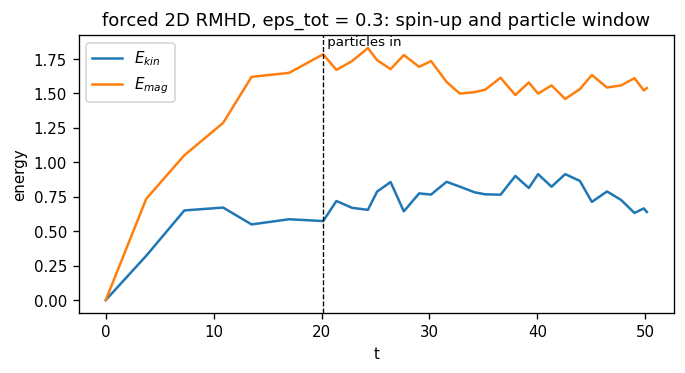

over the particle window: E_kin = 0.763 +- 0.093 (0.574 -> 0.640), E_mag = 1.612 +- 0.104 (1.784 -> 1.539)
u_rms = sqrt(2 E_kin) = 1.233; b_rms = 1.795, i.e. delta_B/B0 = 0.180 at B0 = 10 (and 1.80 for the contrast cohort)

2D MHD inverse-cascades <psi^2> to the box scale and -nu k^6 barely damps k = 1, so E_mag climbs through the spin-up before saturating: 0.000 -> 1.784 over the spin-up, then -14% across the particle window (fluctuation 6%). E_kin, which sets delta_u at the particle scales, holds to 12%.


In [6]:
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(np.r_[bts, ats], np.r_[bek, aek], label=r"$E_{kin}$")
ax.plot(np.r_[bts, ats], np.r_[bem, aem], label=r"$E_{mag}$")
ax.axvline(ats[0], color="k", ls="--", lw=0.8)
ax.text(ats[0], ax.get_ylim()[1], " particles in", va="top", fontsize=8)
ax.set_xlabel("t"); ax.set_ylabel("energy"); ax.set_title(
    f"forced 2D RMHD, eps_tot = {R.EPS_SHOW:g}: spin-up and particle window")
ax.legend()
plt.show()

urms = np.sqrt(2*aek)
print(f"over the particle window: E_kin = {aek.mean():.3f} +- {aek.std():.3f} "
      f"({aek[0]:.3f} -> {aek[-1]:.3f}), E_mag = {aem.mean():.3f} +- {aem.std():.3f} "
      f"({aem[0]:.3f} -> {aem[-1]:.3f})")
print(f"u_rms = sqrt(2 E_kin) = {urms.mean():.3f}; "
      f"b_rms = {np.sqrt(2*aem.mean()):.3f}, i.e. delta_B/B0 = "
      f"{np.sqrt(2*aem.mean())/R.B0_PROD:.3f} at B0 = {R.B0_PROD:g} "
      f"(and {np.sqrt(2*aem.mean())/R.B0_LOW:.2f} for the contrast cohort)")
print(f"\n2D MHD inverse-cascades <psi^2> to the box scale and -nu k^6 barely damps k = 1, so "
      f"E_mag climbs through the spin-up before saturating: {bem[0]:.3f} -> {bem[-1]:.3f} over "
      f"the spin-up, then {aem[-1]/aem[0]-1:+.0%} across the particle window (fluctuation "
      f"{aem.std()/aem.mean():.0%}). E_kin, which sets delta_u at the particle scales, holds "
      f"to {aek.std()/aek.mean():.0%}.")

### Time-averaged spectra, the resolution check and the bottleneck

$E_u(k_\perp)$ and $E_b(k_\perp)$ averaged over the particle window's snapshots.
$\delta u(\rho)$ — the velocity at the gyroradius, which sets $\xi$ — is read off this curve
at $k=1/\rho$ with the convention $\langle u^2\rangle = 2\int E_u\,dk$, i.e.
$\delta u(k) = \sqrt{2kE_u(k)}$ (`diagnostics.particles.delta_u`). The vertical ticks mark
$1/\rho$ for the ensembles that will be fitted.

Hyperviscosity buys inertial range at the price of a bottleneck — a pile-up just below the
dissipation range. The third panel is the check that matters here: every fitted ensemble's
$k_\rho = 1/\rho$ must sit in the power-law stretch, well below the bottleneck. Note also
that Xia et al. used *Laplacian* viscosity at $Re\le3.8\times10^4$; $-\nu k^6$ is a synthetic
inertial range, not a Reynolds number, and the exponents below inherit that.

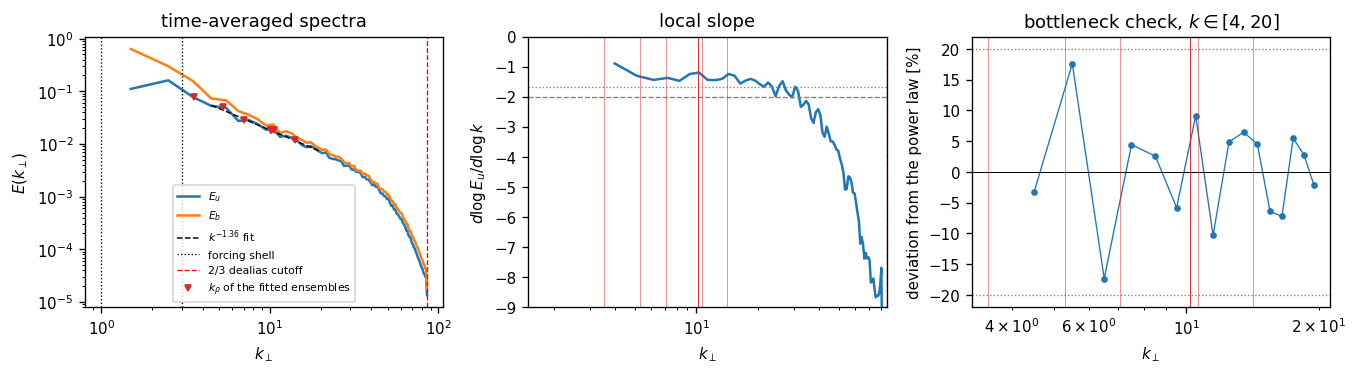

E_u peaks at k = 2.5; at the 2/3 cutoff k = 85.3 it is 1.03e-04 of the peak (4.0 decades down)
local slope crosses -2 (dissipation onset) at k = 29
power law over k in [4, 20]: E_u ~ k^-1.36; deviations -17% .. +18% (rms 8%) -- scatter, not a coherent hump
  => delta_u = sqrt(2 k E_u) ~ k^-0.18, i.e. delta_u ~ rho^+0.18 over that band: the lever a scan that moves only rho has on delta_u, and through it on xi
fitted ensembles sample k_rho in [3.5, 14.1], i.e. rho/dx in [2.9, 11.5] AT INSERTION (v_perp, and with it rho, moves once the particles pick up the E x B drift -- the measured values are in the heating table below)
  k=  5: E_u=5.080e-02  local slope -1.27  delta_u=0.712
  k= 10: E_u=1.874e-02  local slope -1.21  delta_u=0.612
  k= 14: E_u=1.235e-02  local slope -1.30  delta_u=0.587
  k= 20: E_u=6.987e-03  local slope -1.53  delta_u=0.528
  k= 30: E_u=3.628e-03  local slope -1.82  delta_u=0.465
  k= 40: E_u=1.764e-03  local slope -2.52  delta_u=0.375
  k= 60: E_u=3.760e-04  local 

In [7]:
_spec = {}
def mean_spectrum(path, params, kgrid, steps):
    key = (path, tuple(steps))
    if key in _spec:
        return _spec[key]
    ku = eu = eb = None
    for i in steps:
        s = load_state(path, i, params)
        # kinetic_spectrum defaults to bin_factor=1.0, perpspec to 2.0 -- pin both
        k, su = dpart.kinetic_spectrum(s, kgrid, params, bin_factor=1.0)
        _k, _su, sb = diag.perpspec(s, kgrid, params, bin_factor=1.0)
        ku = k if ku is None else ku
        eu = su if eu is None else eu + su
        eb = np.asarray(sb) if eb is None else eb + np.asarray(sb)
    _spec[key] = (ku, eu/len(steps), eb/len(steps))
    return _spec[key]

def local_slope(k, E, w=7):
    '''d log E / d log k on a w-bin log-space stencil: at bin_factor=1 the raw bin-to-bin
    difference is dominated by the lattice's shell-population jitter, not by the spectrum.'''
    ker = np.ones(w)/w
    lks = np.convolve(np.log(k), ker, mode="valid")
    return np.exp(lks), np.gradient(np.convolve(np.log(E), ker, mode="valid"), lks)

def omega_of(ens):
    return abs(dpart.gyrofrequency(ens["qm"], ens["B0"]))

def vperp0(ens):
    init = ens["init"]
    return np.sqrt(2.0)*init["vth"] if init["kind"] == "maxwellian" else init["vperp"]

k_a, Eu_a, Eb_a = mean_spectrum(path_a, params_a, kgrid, asteps)
fit_idx = list(idx_a["sweep"]) + list(idx_a["rings"])
rho_a = np.array([float(dpart.gyroradius(vperp0(e), e["qm"], e["B0"]))
                  for e in params_a.particles["ensembles"]])

good = (k_a > 0) & (Eu_a > 0)
kk, uu = k_a[good], Eu_a[good]
ks, slope = local_slope(kk, uu)
kcut = (2.0/3.0)*(R.NX//2)*(2*np.pi/R.LX)

# power law fitted over the band the particles sample, and the deviation from it
K0, K1 = 4.0, 20.0
band = (kk >= K0) & (kk <= K1)
pl = np.polyfit(np.log(kk[band]), np.log(uu[band]), 1)
dev = uu[band]/np.exp(np.polyval(pl, np.log(kk[band]))) - 1.0

fig, ax = plt.subplots(1, 3, figsize=(11.4, 3.2))
ax[0].loglog(kk, uu, label=r"$E_u$")
ax[0].loglog(k_a[good], Eb_a[good], label=r"$E_b$")
ax[0].loglog(kk[band], np.exp(np.polyval(pl, np.log(kk[band]))), "k--", lw=0.9,
             label=r"$k^{%.2f}$ fit" % pl[0])
for j, kf in enumerate(R.FSHELL):
    ax[0].axvline(kf, color="k", ls=":", lw=0.8, label="forcing shell" if j == 0 else None)
ax[0].axvline(kcut, color="r", ls="--", lw=0.8, label="2/3 dealias cutoff")
for j, e in enumerate(fit_idx):
    ax[0].plot([1.0/rho_a[e]], [np.interp(1.0/rho_a[e], kk, uu)], "v", ms=4, color="C3",
               label=r"$k_\rho$ of the fitted ensembles" if j == 0 else None)
ax[0].set_xlabel(r"$k_\perp$"); ax[0].set_ylabel(r"$E(k_\perp)$")
ax[0].legend(fontsize=6.5); ax[0].set_title("time-averaged spectra")

ax[1].semilogx(ks, slope)
ax[1].axvline(kcut, color="r", ls="--", lw=0.8)
ax[1].axhline(-5/3, color="grey", ls=":", lw=0.8)
ax[1].axhline(-2.0, color="grey", ls="--", lw=0.8)
for e in fit_idx:
    ax[1].axvline(1.0/rho_a[e], color="C3", lw=0.5, alpha=0.6)
ax[1].set_ylim(-9, 0); ax[1].set_xlim(kk[0], kk[-1])
ax[1].set_xlabel(r"$k_\perp$")
ax[1].set_ylabel(r"$d\log E_u/d\log k$"); ax[1].set_title("local slope")

ax[2].semilogx(kk[band], 100*dev, "o-", ms=3, lw=0.8)
ax[2].axhline(0, color="k", lw=0.6)
ax[2].axhline(20, color="grey", ls=":", lw=0.8); ax[2].axhline(-20, color="grey", ls=":", lw=0.8)
for e in fit_idx:
    ax[2].axvline(1.0/rho_a[e], color="C3", lw=0.5, alpha=0.6)
ax[2].set_xlabel(r"$k_\perp$"); ax[2].set_ylabel("deviation from the power law [%]")
ax[2].set_title(r"bottleneck check, $k\in[%g,%g]$" % (K0, K1))
plt.tight_layout(); plt.show()

pk = uu.max()
kdiss = float(ks[np.argmax(slope < -2.0)]) if np.any(slope < -2.0) else np.nan
print(f"E_u peaks at k = {kk[np.argmax(uu)]:.1f}; at the 2/3 cutoff k = {kcut:.1f} it is "
      f"{np.interp(kcut, kk, uu)/pk:.2e} of the peak "
      f"({np.log10(pk/np.interp(kcut, kk, uu)):.1f} decades down)")
print(f"local slope crosses -2 (dissipation onset) at k = {kdiss:.0f}")
print(f"power law over k in [{K0:g}, {K1:g}]: E_u ~ k^{pl[0]:.2f}; deviations "
      f"{100*dev.min():+.0f}% .. {100*dev.max():+.0f}% (rms {100*np.std(dev):.0f}%) -- "
      f"scatter, not a coherent hump")
print(f"  => delta_u = sqrt(2 k E_u) ~ k^{0.5*(1+pl[0]):+.2f}, i.e. "
      f"delta_u ~ rho^{-0.5*(1+pl[0]):+.2f} over that band: the lever a scan that moves "
      f"only rho has on delta_u, and through it on xi")
print(f"fitted ensembles sample k_rho in [{min(1/rho_a[fit_idx]):.1f}, "
      f"{max(1/rho_a[fit_idx]):.1f}], i.e. rho/dx in "
      f"[{min(rho_a[fit_idx])/dx:.1f}, {max(rho_a[fit_idx])/dx:.1f}] AT INSERTION "
      f"(v_perp, and with it rho, moves once the particles pick up the E x B drift -- the "
      f"measured values are in the heating table below)")
for kq in (5, 10, 14, 20, 30, 40, 60, 80):
    print(f"  k={kq:3d}: E_u={np.interp(kq, kk, uu):.3e}  local slope "
          f"{np.interp(kq, ks, slope):+.2f}  delta_u={dpart.delta_u(kk, uu, 1.0/kq):.3f}")

## The ensembles

`n` in `params.particles` is the count **per ensemble**. Every ensemble carries a static mask
over the five field pieces `(bperp, eperp, ez_ideal, ez_resistive, ez_forcing)` — the default
is the ideal-Ohm particle — plus its own `B0` and `epar_project` flag. $\rho/dx\ge2$ is the
floor bilinear interpolation needs; $\Omega\,dt$ is the gyration resolution at the run's
adaptive timestep.

In [8]:
mom_a = dpart.read_moments(path_a)
dt_a = float(np.median(np.diff(mom_a["t"])))
print(f"{'#':>2}  {'label':<34} {'Omega':>6} {'B0':>4} {'q/m':>6} {'init':<18} "
      f"{'rho/dx':>7} {'Om*dt':>6} {'proj':>5}  mask")
for e, ens in enumerate(params_a.particles["ensembles"]):
    init = ens["init"]
    ini = (f"maxwellian vth={init['vth']:g}" if init["kind"] == "maxwellian"
           else f"ring v_perp={init['vperp']:g}")
    on = ",".join(p for p in FIELD_PIECES if ens["mask"][p]) or "none (B0 zhat only)"
    print(f"{e:>2}  {labels_a[e]:<34} {omega_of(ens):6.1f} {ens['B0']:4g} {ens['qm']:6.3f} "
          f"{ini:<18} {rho_a[e]/dx:7.2f} {omega_of(ens)*dt_a:6.3f} "
          f"{str(ens['epar_project']):>5}  {on}")
print(f"\nmedian solver dt over the particle run = {dt_a:.2e} "
      f"({2*np.pi/(R.OM_REF*dt_a):.0f} steps per gyration at Omega = {R.OM_REF:g}, "
      f"{2*np.pi/(max(omega_of(e) for e in params_a.particles['ensembles'])*dt_a):.0f} at the "
      f"largest Omega)")

 #  label                               Omega   B0    q/m init                rho/dx  Om*dt  proj  mask
 0  (a) Omega = 5, B0 = 10                5.0   10  0.500 maxwellian vth=1     11.52  0.007  True  bperp,eperp,ez_ideal
 1  (a) Omega = 7.5, B0 = 10              7.5   10  0.750 maxwellian vth=1      7.68  0.010  True  bperp,eperp,ez_ideal
 2  (a) Omega = 10, B0 = 10              10.0   10  1.000 maxwellian vth=1      5.76  0.013  True  bperp,eperp,ez_ideal
 3  (a) Omega = 15, B0 = 10              15.0   10  1.500 maxwellian vth=1      3.84  0.020  True  bperp,eperp,ez_ideal
 4  (a) Omega = 20, B0 = 10              20.0   10  2.000 maxwellian vth=1      2.88  0.026  True  bperp,eperp,ez_ideal
 5  (c) ring v_perp = 0.5, Omega = 5.1    5.1   10  0.509 ring v_perp=0.5       4.00  0.007  True  bperp,eperp,ez_ideal
 6  (c) ring v_perp = 1, Omega = 10.2    10.2   10  1.019 ring v_perp=1         4.00  0.013  True  bperp,eperp,ez_ideal
 7  (c) ring v_perp = 2, Omega = 20.4    20.4   10  2.03

## Energy bookkeeping

`ParticleState.w` accumulates the work per unit mass done by each electric piece, credited
inside the pusher from the exact Boris half-kick identity
$\Delta(\tfrac12|v|^2) = h\,\mathbf{E}\cdot(\mathbf{v}_{in}+\mathbf{v}_{new})$. Summing the
pieces must therefore reproduce the kinetic-energy change to round-off — the `closure` column
— which is what makes the heating *attribution* a measurement rather than an inference. A
piece an ensemble's mask omits stays exactly zero. With the projection on, the columns
attribute the *projected* field's work, so the closure is exact there too.

In [9]:
p_first = sn.load_particles(asteps[0], path_a, params_a)
p_last = sn.load_particles(asteps[-1], path_a, params_a)
bud = dpart.energy_budget(p_last, p_first)
ke0 = float(np.mean(0.5*np.sum(np.asarray(p_first.v)**2, axis=2)))

hdr = "  ".join(f"{p:>12}" for p in WORK_PIECES)
print(f"work per unit mass over t = {ats[0]:.1f} -> {ats[-1]:.1f} "
      f"(initial <KE> per unit mass = {ke0:.3f})\n")
print(f"{'#':>2}  {'ensemble':<34} {'d<KE>':>10}  {hdr}  {'total':>10}  {'closure/d<KE>':>13}")
for e in range(len(labels_a)):
    w = "  ".join(f"{v:12.3e}" for v in bud["work"][e])
    # a control does no work at all: closure = d<KE> = round-off, so the ratio is 0/0 and
    # the 1.00 it would print is not a closure check
    rel = ("n/a (0/0)" if bud["total_work"][e] == 0.0
           else f"{bud['closure'][e]/bud['dke'][e]:.2e}")
    print(f"{e:>2}  {labels_a[e]:<34} {bud['dke'][e]:10.3e}  {w}  "
          f"{bud['total_work'][e]:10.3e}  {rel:>13}")
works = bud["total_work"] != 0.0
print(f"\nlargest |closure| over the {int(works.sum())} ensembles that do work: "
      f"{np.max(np.abs(bud['closure'][works])):.2e} "
      f"({np.max(np.abs(bud['closure'][works]))/ke0:.1e} of the initial KE)")
print("the two control rows are n/a rather than 1.00: their work columns are exactly zero "
      "and their d<KE> is round-off, so closure/d<KE> is 0/0. Their floor is the "
      "per-particle |v|^2 drift measured next, not a closure ratio.")

work per unit mass over t = 20.1 -> 50.1 (initial <KE> per unit mass = 1.788)

 #  ensemble                                d<KE>         eperp      ez_ideal  ez_resistive    ez_forcing       total  closure/d<KE>
 0  (a) Omega = 5, B0 = 10              4.821e+00     4.657e+00     1.643e-01     0.000e+00     0.000e+00   4.821e+00      -3.32e-15
 1  (a) Omega = 7.5, B0 = 10            5.312e+00     5.047e+00     2.649e-01     0.000e+00     0.000e+00   5.312e+00      -8.36e-16
 2  (a) Omega = 10, B0 = 10             5.492e+00     5.051e+00     4.412e-01     0.000e+00     0.000e+00   5.492e+00       1.29e-15
 3  (a) Omega = 15, B0 = 10             5.676e+00     5.178e+00     4.983e-01     0.000e+00     0.000e+00   5.676e+00      -2.97e-15
 4  (a) Omega = 20, B0 = 10             5.894e+00     5.042e+00     8.519e-01     0.000e+00     0.000e+00   5.894e+00       9.04e-16
 5  (c) ring v_perp = 0.5, Omega = 5.1  5.536e+00     5.434e+00     1.029e-01     0.000e+00     0.000e+00   5.536e+00      

In [10]:
# the two controls, per particle rather than per ensemble
v0 = np.asarray(p_first.v); v1 = np.asarray(p_last.v)
rel = np.abs(np.sum(v1**2, axis=2)/np.sum(v0**2, axis=2) - 1.0)
for name, e in (("E = 0 control", idx_a["e_zero"]), ("delta-b = 0 control", idx_a["gyration"])):
    print(f"{name:22s}: max per-particle |v|^2 drift {rel[e].max():.2e}, "
          f"mean {rel[e].mean():.2e}; w exactly zero: "
          f"{bool(np.all(np.asarray(p_last.w[e]) == 0.0))}")
for name, e in (("ideal Omega=10", idx_a["ideal_ref"]), ("full dpsi/dt", idx_a["full"])):
    print(f"{name:22s}: mean per-particle |v|^2 change {rel[e].mean():.3f}")
print("\nthe E = 0 ensemble's drift is the numerical-heating FLOOR every rate below is "
      "quoted against.")

E = 0 control         : max per-particle |v|^2 drift 6.37e-14, mean 1.25e-14; w exactly zero: True
delta-b = 0 control   : max per-particle |v|^2 drift 5.91e-14, mean 9.23e-15; w exactly zero: True
ideal Omega=10        : mean per-particle |v|^2 change 11.262
full dpsi/dt          : mean per-particle |v|^2 change 13.900

the E = 0 ensemble's drift is the numerical-heating FLOOR every rate below is quoted against.


## Magnetic moment

$\mu = v_{\perp B}^2/2|B|$ about the **local** field, tracked two ways: the per-step sidecar
column (the pusher's own last $B$ sample, no extra gather) and, at snapshot cadence,
`mu_of`. $D_\mu$ is quoted both as $\tfrac12\,d\,\mathrm{Var}(\mu)/dt$ from the sidecar and
as the snapshot-pair estimator $\tfrac12\langle(\Delta\mu)^2\rangle/\Delta t$. The two are
**not** two estimates of the same number here, and the printout below says why: the pair
estimator counts a reversible $\mu$ oscillation as diffusion, and at this snapshot interval
(about two gyroperiods) that is most of what it sees.

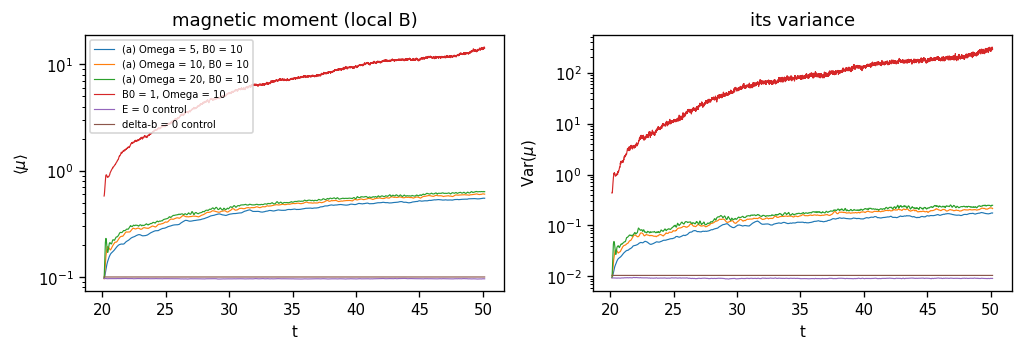

 #  ensemble                             <mu> end   D_mu (sidecar)   D_mu (pairs)
 0  (a) Omega = 5, B0 = 10                  0.552   2.21e-03+-7e-04       2.71e-02
 1  (a) Omega = 7.5, B0 = 10                0.591   2.42e-03+-7e-04       3.88e-02
 2  (a) Omega = 10, B0 = 10                 0.603   2.64e-03+-1e-03       4.76e-02
 3  (a) Omega = 15, B0 = 10                 0.619   2.90e-03+-9e-04       5.49e-02
 4  (a) Omega = 20, B0 = 10                 0.636   3.06e-03+-9e-04       5.55e-02
 5  (c) ring v_perp = 0.5, Omega = 5.1      0.529   2.11e-03+-8e-04       2.58e-02
 6  (c) ring v_perp = 1, Omega = 10.2       0.599   2.60e-03+-1e-03       4.55e-02
 7  (c) ring v_perp = 2, Omega = 20.4       0.624   2.86e-03+-1e-03       5.54e-02
 8  (c) ring v_perp = 4, Omega = 40.7       0.808   2.30e-03+-1e-03       9.31e-02
 9  B0 = 1, Omega = 5                       9.159   1.65e+00+-5e-01       2.20e+01
10  B0 = 1, Omega = 10                     14.285   4.58e+00+-1e+00       5.28e+01
11  B

In [11]:
show = [idx_a["sweep"][0], idx_a["ideal_ref"], idx_a["sweep"][-1], idx_a["lowB0"][1],
        idx_a["e_zero"], idx_a["gyration"]]
fig, ax = plt.subplots(1, 2, figsize=(8.6, 3.0))
for e in show:
    ax[0].plot(mom_a["t"], mom_a["mu"][:, e], lw=0.7, label=labels_a[e])
    var = mom_a["mu2"][:, e] - mom_a["mu"][:, e]**2
    ax[1].plot(mom_a["t"], var, lw=0.7)
ax[0].set_xlabel("t"); ax[0].set_ylabel(r"$\langle\mu\rangle$"); ax[0].legend(fontsize=6)
ax[1].set_xlabel("t"); ax[1].set_ylabel(r"$\mathrm{Var}(\mu)$")
# log y: mu ~ 1/B0, so the B0 = 1 cohort sits a decade above the rest and the controls a
# decade below
for a in ax:
    a.set_yscale("log")
ax[0].set_title("magnetic moment (local B)"); ax[1].set_title("its variance")
plt.tight_layout(); plt.show()

t_fit0 = ats[0] + 0.1*(ats[-1] - ats[0])
D, Derr = dpart.mu_diffusion(mom_a, t0=t_fit0)
mus = [dpart.mu_of(sn.load_particles(i, path_a, params_a), load_state(path_a, i, params_a),
                   kgrid, params_a) for i in asteps]
dt_pair = float(np.mean(np.diff(ats)))
Dpair = np.mean([dpart.increment_diffusion(mus[j], mus[j+1], ats[j+1]-ats[j])
                 for j in range(len(asteps)-1)], axis=0)
print(f"{'#':>2}  {'ensemble':<34} {'<mu> end':>10} {'D_mu (sidecar)':>16} {'D_mu (pairs)':>14}")
for e in range(len(labels_a)):
    print(f"{e:>2}  {labels_a[e]:<34} {mom_a['mu'][-1, e]:10.3f} "
          f"{D[e]:10.2e}+-{Derr[e]:.0e} {Dpair[e]:14.2e}")

# the snapshot-cadence mu_of and the per-step sidecar column are independent evaluations of
# the same definition (different B samples: gathered at x_n vs the pusher's last half-kick
# sample), so they should agree to the field's variation over one step
j = len(asteps)//2
row = int(np.argmin(np.abs(mom_a["t"] - ats[j])))
print(f"\nmu_of vs sidecar at t = {ats[j]:.3f} (nearest row t = {mom_a['t'][row]:.3f}): "
      f"max relative difference over the ensembles "
      f"{np.max(np.abs(mus[j].mean(axis=1)/mom_a['mu'][row] - 1.0)):.2e}")

heated = list(idx_a["sweep"]) + list(idx_a["rings"]) + list(idx_a["lowB0"])
ratio = Dpair[heated]/D[heated]
ez = idx_a["e_zero"]
print(f"\nthe two D_mu columns disagree by {ratio.min():.0f}-{ratio.max():.0f}x, and the "
      f"sidecar one is the one to quote. The pair estimator uses the increment over a "
      f"snapshot interval dt = {dt_pair:.2f} -- {dt_pair*R.OM_REF/(2*np.pi):.0f} "
      f"gyroperiods at Omega = {R.OM_REF:g} -- so REVERSIBLE gyrophase and mirror "
      f"oscillation of mu enters <(dmu)^2> exactly like diffusion; the variance slope does "
      f"not see it. The E = 0 control is the demonstration: its mu cannot diffuse at all "
      f"(no electric field), and it gives D_mu(sidecar) = {D[ez]:.1e} +- {Derr[ez]:.0e}, "
      f"consistent with zero, against D_mu(pairs) = {Dpair[ez]:.1e}. Read the pair values "
      f"as an upper bound at this cadence.")

## Headline 1 — $Q_\perp(\xi)$ from three scan designs

Measurement protocol, following Xia et al. (2013) §4.1. What the next cell actually does,
in the order it does it:

- the perpendicular energy is the **local-$\mathbf B$** one,
  $\tfrac12\langle v_{\perp B}^2\rangle$ (sidecar column `vperpB2`, one row per solver step),
  smoothed with a 101-step running mean; the parallel one is `vparB2`, and the
  $\hat z$-referred pair (`vperp2`, `vz2`) is reported next to them so the frame effect is
  visible;
- the window **starts** at $t_0 = 10/\Omega$ after the particles are introduced — they are
  launched with no $\mathbf E\times\mathbf B$ drift and pick it up within a few
  gyroperiods, and at $u_{rms}\sim v_{th}$ that transient is an $O(1)$ contribution to
  $\langle v_\perp^2\rangle$ (their Fig. 2);
- it **ends** at the first step where the smoothed $\langle v_{\perp B}^2\rangle$ exceeds
  $1.2\times$ its $t_0$ value, or at the run end — but never sooner than `NMIN` = 400 solver
  steps, because the block-slope error needs a fittable window. The **`ext`** column flags
  the points where that floor, not the $1.2\times$ rule, ended the window; their `grow`
  column reads 25–33% instead of 20%, so their $\xi$ is a slightly worse label for the
  window than the others'. (Where the window instead ran to the end of the run, `grow` is
  small or negative — those are the suppressed ensembles, and they come out as limits.)
- $\rho = v_\perp/\Omega$ and $\xi = \delta u(\rho)/v_\perp$ use $v_\perp$ **at $t_0$**, not
  at insertion: by $t_0$ a particle carries the $\mathbf E\times\mathbf B$ drift and whatever
  heating preceded $t_0$, and both are in the table's `v_perp` and `rho/dx` columns — which
  is why those columns do not reproduce the design values printed with the ensembles;
- $\delta u(\rho)$ comes from the run's own kinetic spectrum time-averaged over the
  snapshots **inside** the window. A window can be shorter than the snapshot cadence
  ($t_{snap} = 1.2$ at $\varepsilon_{tot} = 0.3$ against windows of $\sim0.7$) and hold
  none, and those points fall back to the whole-run average instead: the **`nsp`** column is
  the in-window count, and the line under the tables bounds what that substitution can be
  worth.

Because $u_{rms}\approx1$ here — comparable to $v_{th}$ — the lab-frame $v_\perp$ contains a
large $\mathbf E\times\mathbf B$ drift contribution as well as the gyration. Both the
lab-frame $v_\perp$ (what is measured) and the drift-corrected
$\sqrt{v_{\perp B}^2 - \langle u^2\rangle}$ (closer to the gyro-frame speed the theory means)
are carried through the fits, and every $c_2$ below says which one it used.

**The exclusion rule.** A window whose $Q_\perp$ is not $2\sigma$ above zero is an **upper
limit**, not a measurement: it is starred in the tables, drawn as an arrow in the plot, held
out of every fit, and used quantitatively further down, where the limits turn out to be the
most informative points in the dataset.

In [12]:
def _smooth(y, w):
    '''running mean over w samples, edge-padded so the ends are not biased low.'''
    w = max(1, min(w | 1, (len(y)//4) | 1))
    pad = w//2
    return np.convolve(np.pad(y, pad, mode="edge"), np.ones(w)/w, mode="valid")

NMIN = 400        # the window floor in solver steps (see the rule above)

def heating_points(run, which, frac=0.2, nblocks=5):
    '''One (Q, xi) point per ensemble index in `which`, for one particle run (a
    `R.particle_run(...)` tuple), by the rule stated above: start at t0 = 10/Omega, end at
    the first step where the smoothed <v_perpB^2> exceeds (1+frac) times its t0 value or at
    the run end, never shorter than NMIN steps (`ext` flags the points where that floor
    bound); v_perp, rho and xi at t0; delta_u from the kinetic spectrum averaged over the
    snapshots INSIDE the window, falling back to the whole run when there are none (`nsp`
    is the in-window count, and `du_all` is the whole-run value for comparison).'''
    params, path, labels, idx = run
    kg = jr.setup_kgrids(params)
    steps, ts = snap_index(path, params)
    mom = dpart.read_moments(path)
    t = mom["t"]
    k_all, Eu_all, _Eb_all = mean_spectrum(path, params, kg, steps)
    keys = ("e", "label", "om", "B0", "Q", "Qerr", "Qpar", "Qparerr", "Qz", "Qzerr", "Qzz",
            "t0", "t1", "grow", "ext", "nsp", "vperp", "rho", "du", "du_all", "xi",
            "vperp_g", "rho_g", "du_g", "xi_g", "ekin")
    out = {key: [] for key in keys}
    for e in which:
        ens = params.particles["ensembles"][e]
        om = abs(ens["qm"]*ens["B0"])
        f = _smooth(mom["vperpB2"][:, e], 101)
        nmin = min(NMIN, max(2*nblocks, len(t)//4))     # keep the window fittable
        i0 = min(int(np.searchsorted(t, t[0] + 10.0/om)), len(t) - 1 - nmin)
        over = np.where(f[i0:] > f[i0]*(1.0 + frac))[0]
        i1_rule = i0 + int(over[0]) if over.size else len(t) - 1
        i1 = max(i1_rule, min(len(t) - 1, i0 + nmin))
        t0, t1 = float(t[i0]), float(t[i1])
        # the window's own time-averaged spectrum and E_kin
        inwin = [s for s, tt in zip(steps, ts) if t0 <= tt <= t1]
        win = inwin or list(steps)
        k, Eu, _Eb = mean_spectrum(path, params, kg, win)
        ekin = float(np.mean(energies(path, params, kg, win)[0]))
        Q, Qerr = dpart.heating_rate(mom, "vperpB2", t0=t0, t1=t1, nblocks=nblocks)
        Qp, Qperr = dpart.heating_rate(mom, "vparB2", t0=t0, t1=t1, nblocks=nblocks)
        Qz, Qzerr = dpart.heating_rate(mom, "vperp2", t0=t0, t1=t1, nblocks=nblocks)
        Qzz, _ = dpart.heating_rate(mom, "vz2", t0=t0, t1=t1, nblocks=nblocks)
        vp2 = float(f[i0])
        for suf, vp in (("", np.sqrt(vp2)),
                        ("_g", np.sqrt(max(vp2 - 2.0*ekin, 1e-12)))):
            rho = float(dpart.gyroradius(vp, ens["qm"], ens["B0"]))
            out["vperp"+suf].append(vp); out["rho"+suf].append(rho)
            out["du"+suf].append(float(dpart.delta_u(k, Eu, rho)))
            out["xi"+suf].append(float(dpart.xi(out["du"+suf][-1], vp)))
        out["du_all"].append(float(dpart.delta_u(k_all, Eu_all, out["rho"][-1])))
        out["e"].append(e); out["label"].append(labels[e]); out["om"].append(om)
        out["B0"].append(ens["B0"]); out["ekin"].append(ekin)
        out["Q"].append(float(Q[e])); out["Qerr"].append(float(Qerr[e]))
        out["Qpar"].append(float(Qp[e])); out["Qparerr"].append(float(Qperr[e]))
        out["Qz"].append(float(Qz[e])); out["Qzerr"].append(float(Qzerr[e]))
        out["Qzz"].append(float(Qzz[e]))
        out["t0"].append(t0); out["t1"].append(t1)
        out["grow"].append(float(f[i1]/f[i0] - 1.0))
        out["ext"].append(bool(i1 > i1_rule)); out["nsp"].append(len(inwin))
    return {key: np.array(v) for key, v in out.items()}

HDR = (f"{'run':<40} {'window':>13} {'grow':>5} {'ext':>4} {'nsp':>4} {'v_perp':>7} "
       f"{'rho/dx':>7} {'du':>6} {'xi':>6} {'Q_perp(B)':>16} {'Q_par(B)':>10} "
       f"{'Q_perp(z)':>10} {'Q_z(z)':>10}")

def show_points(p, prefix):
    for j in range(len(p["e"])):
        # "*" marks a rate that is not 2 sigma above zero: an upper limit, which is NOT a
        # measurement and does not enter any fit below
        star = "*" if p["Q"][j] <= 2*p["Qerr"][j] else " "
        print(f"{prefix + p['label'][j]:<40} {p['t0'][j]:6.1f}-{p['t1'][j]:5.1f} "
              f"{p['grow'][j]*100:4.0f}% {('yes' if p['ext'][j] else '-'):>4} "
              f"{p['nsp'][j]:4d} {p['vperp'][j]:7.3f} {p['rho'][j]/dx:7.2f} "
              f"{p['du'][j]:6.3f} {p['xi'][j]:6.3f} "
              f"{p['Q'][j]:9.2e}+-{p['Qerr'][j]:.0e}{star}{p['Qpar'][j]:10.2e} "
              f"{p['Qz'][j]:10.2e} {p['Qzz'][j]:10.2e}")

pts_a, pts_c, pts_low, pts_b = {}, {}, {}, {}
for eps in R.A_HOSTS:
    run = R.particle_run("a", eps)
    pts_a[eps] = heating_points(run, list(run[3]["sweep"]))
    pts_c[eps] = heating_points(run, list(run[3]["rings"]))
    pts_low[eps] = heating_points(run, list(run[3]["lowB0"]))
for eps in R.EPS_LADDER:
    run = R.particle_run("b", eps)
    pts_b[eps] = heating_points(run, [run[3]["ideal_ref"]])

print("design (a): Omega sweep at fixed v_th, B0 = %g\n" % R.B0_PROD + HDR)
for eps in R.A_HOSTS:
    show_points(pts_a[eps], f"eps={eps:g}  ")
print("\ndesign (c): rho fixed AT INSERTION at rho/dx = %g, rings at several v_perp\n"
      % (R.RHO_C/dx) + HDR)
for eps in R.A_HOSTS:
    show_points(pts_c[eps], f"eps={eps:g}  ")
print("\ndesign (b): eps_tot sweep at Omega = %g, v_th = %g\n" % (R.OM_REF, R.VTH) + HDR)
for eps in R.EPS_LADDER:
    show_points(pts_b[eps], f"eps={eps:g}  ")
print("\nB0 = 1 contrast cohort (same Omega, same rho; delta_B/B0 ten times larger)\n" + HDR)
for eps in R.A_HOSTS:
    show_points(pts_low[eps], f"eps={eps:g}  ")

ALLP = ([pts_a[e] for e in R.A_HOSTS] + [pts_c[e] for e in R.A_HOSTS]
        + [pts_b[e] for e in R.EPS_LADDER] + [pts_low[e] for e in R.A_HOSTS])
FITP = ALLP[:len(R.A_HOSTS)*2 + len(R.EPS_LADDER)]      # (a), (c), (b): the fitted designs
nall = sum(len(p["e"]) for p in FITP)
nlim = sum(int((p["Q"] <= 2*p["Qerr"]).sum()) for p in FITP)
next_ = sum(int(p["ext"].sum()) for p in ALLP)
nfall = sum(int((p["nsp"] == 0).sum()) for p in ALLP)
ntot = sum(len(p["e"]) for p in ALLP)
dud = np.concatenate([p["du"]/p["du_all"] - 1.0 for p in ALLP])
has = np.concatenate([p["nsp"] > 0 for p in ALLP])
print(f"\nthe three fitted designs (a)+(b)+(c) hold {nall} points, of which {nlim} are "
      f"upper limits (*) and {nall-nlim} are measurements. Only the {nall-nlim} enter the "
      f"fits below.")
print(f"window bookkeeping over all {ntot} points including the B0 = 1 cohort: the "
      f"NMIN = {NMIN}-step floor bound the window in {next_} of them (their grow column "
      f"reads 25-33%, or negative where the window ran to the end of the run instead), and "
      f"{nfall} windows are shorter than the snapshot cadence and hold no snapshot at all, "
      f"so their delta_u comes from the whole-run spectrum.")
print(f"how much that fallback can matter: over the {int(has.sum())} points that DO have "
      f"in-window snapshots, delta_u(window)/delta_u(whole run) - 1 spans "
      f"{100*dud[has].min():+.0f}%..{100*dud[has].max():+.0f}% (median "
      f"{100*np.median(dud[has]):+.0f}%), and xi is linear in delta_u.")

design (a): Omega sweep at fixed v_th, B0 = 10
run                                             window  grow  ext  nsp  v_perp  rho/dx     du     xi        Q_perp(B)   Q_par(B)  Q_perp(z)     Q_z(z)
eps=0.03  (a) Omega = 5, B0 = 10           44.4- 58.9   20%    -    6   1.518   12.37  0.290  0.191  1.44e-02+-6e-04   2.34e-04   1.44e-02   2.13e-04
eps=0.03  (a) Omega = 7.5, B0 = 10         43.7- 59.0   20%    -    6   1.529    8.30  0.293  0.192  1.34e-02+-2e-03   1.19e-04   1.35e-02   6.45e-05
eps=0.03  (a) Omega = 10, B0 = 10          43.4- 60.4   20%    -    6   1.538    6.27  0.255  0.166  1.31e-02+-3e-03   2.31e-04   1.30e-02   3.20e-04
eps=0.03  (a) Omega = 15, B0 = 10          43.0- 71.6   20%    -   10   1.582    4.30  0.253  0.160  8.53e-03+-4e-03*  3.60e-04   8.50e-03   3.94e-04
eps=0.03  (a) Omega = 20, B0 = 10          42.9- 81.7   20%    -   14   1.547    3.15  0.253  0.163  5.93e-03+-2e-03   1.73e-04   5.91e-03   1.95e-04
eps=0.3  (a) Omega = 5, B0 = 10            22.1- 24.

In [13]:
def cat(dicts, key):
    return np.concatenate([d[key] for d in dicts])

A = [pts_a[e] for e in R.A_HOSTS]
Cc = [pts_c[e] for e in R.A_HOSTS]
B = [pts_b[e] for e in R.EPS_LADDER]
L = [pts_low[e] for e in R.A_HOSTS]
KEYS = list(A[0])
sets = {}
for eps in R.A_HOSTS:
    sets["(a) Omega sweep, eps=%g" % eps] = pts_a[eps]
for eps in R.A_HOSTS:
    sets["(c) fixed rho, eps=%g" % eps] = pts_c[eps]
sets["(a) both hosts"] = {k: cat(A, k) for k in KEYS}
sets["(c) fixed rho, both hosts"] = {k: cat(Cc, k) for k in KEYS}
sets["(b) eps_tot sweep"] = {k: cat(B, k) for k in KEYS}
sets["(b)+(c), no design (a)"] = {k: cat(Cc + B, k) for k in KEYS}
sets["(a)+(b)+(c) combined"] = {k: cat(A + Cc + B, k) for k in KEYS}
sets["B0 = 1 cohort"] = {k: cat(L, k) for k in KEYS}

def fit_err(info):
    '''1-sigma errors on (log c1, c2) from the residual scatter of the 2-parameter fit.'''
    x, used = info["x"][info["used"]], info["used"]
    M = np.stack([np.ones(x.size), -x], axis=1)
    dof = max(x.size - 2, 1)
    s2 = float(np.sum(info["residuals"][used]**2))/dof
    return np.sqrt(np.diag(np.linalg.inv(M.T @ M)*s2))

TAGS = {"lab": ("xi", "rho", "du"), "gyro": ("xi_g", "rho_g", "du_g")}

def fit_one(p, tag="lab", qk="Q", keep=None):
    '''Chandran fit of one point set under the notebook's exclusion rule: a point whose
    rate is not 2 sigma above zero is an UPPER LIMIT and does not enter the log-OLS. Pass
    `keep` to override the rule. Returns both R^2 values -- on log(Q rho/du^3), the
    quantity the two-parameter line is actually fitted to, and on log Q, the quantity the
    power-law comparison below is scored on (identical residuals, different total sum of
    squares, so they are NOT interchangeable).'''
    xk, rk, dk = TAGS[tag]
    q = np.asarray(p[qk], dtype=np.float64)
    if keep is None:
        keep = q > 2.0*np.asarray(p["Qerr" if qk == "Q" else "Qzerr"], dtype=np.float64)
    with np.errstate(invalid="ignore", divide="ignore"):
        c1, c2, info = dpart.chandran_fit(p[xk], np.where(keep, q, np.nan), p[rk], p[dk])
    err = fit_err(info)
    u = info["used"]
    lq = np.log(q[u])
    sst = float(np.sum((lq - lq.mean())**2))
    ssr = float(np.sum(info["residuals"][u]**2))
    return {"c1": c1, "c2": c2, "err": err, "info": info, "used": u, "r2n": info["r2"],
            "r2q": 1.0 - ssr/sst if sst > 0 else np.nan, "n": int(u.sum()),
            "xi": np.asarray(p[xk])[u]}

def fit_line(name, fr):
    x = fr["xi"]
    return (f"{name:<40} c1 = {fr['c1']:7.3f} (x/ {np.exp(fr['err'][0]):5.2f})  "
            f"c2 = {fr['c2']:6.3f} +- {fr['err'][1]:.3f}  R2(norm) {fr['r2n']:6.3f}  "
            f"R2(logQ) {fr['r2q']:6.3f}  n = {fr['n']:2d}  "
            f"xi in [{x.min():.3f}, {x.max():.3f}] (x{x.max()/x.min():.2f})")

print("EXCLUSION RULE, applied everywhere below: a point whose Q_perp is not 2 sigma above "
      "zero is an upper limit and is held OUT of the log-OLS -- the same points the plot "
      "draws as arrows and the limit table quantifies. R2(norm) scores log(Q rho/du^3), "
      "which is what the two-parameter line is fitted to; R2(logQ) scores log Q, which is "
      "what the power-law comparison uses.\n")
fits = {}
for name, p in sets.items():
    nl = int((p["Q"] <= 2*p["Qerr"]).sum())
    for tag in TAGS:
        fr = fit_one(p, tag)
        fits[(name, tag)] = fr
        print(fit_line(f"{name} [{tag:>4} v_perp]", fr)
              + (f"  [{nl} limit(s) held out]" if nl else ""))

comb = sets["(a)+(b)+(c) combined"]
print("\nsensitivity of the headline number to every choice behind it (combined set unless "
      "the row says otherwise):\n")
rows = [("HEADLINE 2-sigma rule, lab v_perp, local-B Q", fit_one(comb, "lab")),
        ("  same, drift-corrected v_perp", fit_one(comb, "gyro")),
        ("  same, Q_perp referred to zhat", fit_one(comb, "lab", qk="Qz",
                                                    keep=comb["Q"] > 2*comb["Qerr"])),
        ("all points, incl. the <=2 sigma ones (Q>0)", fit_one(comb, "lab",
                                                               keep=comb["Q"] > 0)),
        ("  same, drift-corrected v_perp", fit_one(comb, "gyro", keep=comb["Q"] > 0)),
        ("zhat Q with its own 2-sigma rule", fit_one(comb, "lab", qk="Qz")),
        ("zhat Q, every Q_z > 0 (no limit handling)", fit_one(comb, "lab", qk="Qz",
                                                              keep=comb["Qz"] > 0)),
        ("2-sigma rule, without design (a)", fit_one(sets["(b)+(c), no design (a)"], "lab")),
        ("2-sigma rule, design (a) only", fit_one(sets["(a) both hosts"], "lab")),
        ("2-sigma rule, design (b) only, gyro", fit_one(sets["(b) eps_tot sweep"], "gyro")),
        ("B0 = 1 cohort, same protocol", fit_one(sets["B0 = 1 cohort"], "lab"))]
for name, fr in rows:
    print(fit_line(name, fr))
extra = np.where((comb["Qz"] > 0) & (comb["Q"] <= 2*comb["Qerr"]))[0]
print(f"\nthe 'no limit handling' row is the one that admits the {extra.size} point(s) "
      f"whose local-B rate is not 2 sigma positive but whose zhat rate happens to be "
      f"(xi = {', '.join('%.3f' % comb['xi'][j] for j in extra)}) -- that is the size of "
      f"what the exclusion rule protects the fit from, and it is larger than the frame "
      f"change itself.")
print("\nreference values: Chandran et al. 2010 (3D RMHD test particles) c1 ~ 0.75, "
      "c2 ~ 0.34;")
print("Xia et al. 2013 (3D RMHD, beta_i = 0.006-1): c2 = 0.44 at 128^3 falling to 0.20 at "
      "1024^2x256, c1 ~ 0.7-1.1 at beta_i = 0.006 and ~3.7 at beta_i = 1.")

EXCLUSION RULE, applied everywhere below: a point whose Q_perp is not 2 sigma above zero is an upper limit and is held OUT of the log-OLS -- the same points the plot draws as arrows and the limit table quantifies. R2(norm) scores log(Q rho/du^3), which is what the two-parameter line is fitted to; R2(logQ) scores log Q, which is what the power-law comparison uses.

(a) Omega sweep, eps=0.03 [ lab v_perp]  c1 =  43.086 (x/ 122.09)  c2 =  1.092 +- 0.848  R2(norm)  0.453  R2(logQ) -1.012  n =  4  xi in [0.163, 0.192] (x1.17)  [1 limit(s) held out]
(a) Omega sweep, eps=0.03 [gyro v_perp]  c1 =   1.470 (x/ 431.49)  c2 =  0.538 +- 1.139  R2(norm)  0.100  R2(logQ) -2.856  n =  4  xi in [0.175, 0.217] (x1.24)  [1 limit(s) held out]
(a) Omega sweep, eps=0.3 [ lab v_perp]   c1 =   0.000 (x/  1.32)  c2 = -2.006 +- 0.080  R2(norm)  0.997  R2(logQ)  0.996  n =  4  xi in [0.265, 0.331] (x1.25)  [1 limit(s) held out]
(a) Omega sweep, eps=0.3 [gyro v_perp]   c1 =   0.196 (x/  1.53)  c2 = -0.175 +- 0.14

The Chandran normalization assumes $Q_\perp \propto \delta u^3/\rho$ with the whole $\xi$
dependence in the exponential. That is a testable claim on its own: fit the same points to a
pure power law $Q_\perp \propto \delta u^{\,n}\rho^{\,m}$ and see whether $(n,m)$ comes out at
$(3,-1)$.

Design (c) was built to be the clean discriminator — $\rho$ fixed and only $v_\perp$ varying,
so $\delta u(\rho)$ is fixed and a power law in $(\delta u,\rho)$ would predict *no*
variation of $Q_\perp$ across its four points while the exponential predicts a factor
$\exp(-c_2\Delta(1/\xi))$. It only half delivers, and the next cell says by how much: $\rho$
is fixed **at insertion**, and by $t_0$ the $\mathbf E\times\mathbf B$ pickup and the
pre-$t_0$ heating have moved both $v_\perp$ and $\rho$, so the nominal factor 8 in $v_\perp$
is a measured factor 4.6 (at $\varepsilon_{tot} = 0.03$) or 2.2 (at $0.3$) and $\rho$ moves
by 1.7–3.7 instead of not at all. The honest question is therefore not "does $Q_\perp$ vary
at all" but "does it vary by more than the measured $(\delta u,\rho)$ spread accounts for",
which is what the per-host block below computes.

In [14]:
def _r2(y, pred):
    return 1.0 - float(np.sum((y - pred)**2))/float(np.sum((y - y.mean())**2))

print("both models scored on the SAME quantity, log Q, over the SAME points -- the ones "
      "the 2 sigma rule keeps (the exponential has 2 free parameters, the power law 3)\n")
print(f"{'set':<26} {'n_pts':>5} {'R^2 exponential':>16} {'n (du)':>8} {'m (rho)':>8} "
      f"{'R^2 power law':>14}   (Chandran assumes n = 3, m = -1)")
plaw = {}
for name, p in sets.items():
    ok = fits[(name, "lab")]["used"]
    y = np.log(p["Q"][ok])
    r2_exp = fits[(name, "lab")]["r2q"]
    if ok.sum() < 4:
        print(f"{name:<26} {int(ok.sum()):5d} {r2_exp:16.3f} {'--':>8} {'--':>8} "
              f"{'--':>14}   (too few points for a 3-parameter fit)")
        continue
    M = np.stack([np.ones(int(ok.sum())), np.log(p["du"][ok]), np.log(p["rho"][ok])], axis=1)
    coef, *_ = np.linalg.lstsq(M, y, rcond=None)
    plaw[name] = coef
    print(f"{name:<26} {int(ok.sum()):5d} {r2_exp:16.3f} {coef[1]:8.2f} {coef[2]:8.2f} "
          f"{_r2(y, M @ coef):14.3f}")

# What design (c) actually predicts. rho is fixed AT INSERTION; by t0 the rings carry the
# E x B drift and whatever heating preceded t0, so v_perp and rho have both moved and the
# "a power law predicts no variation across (c)" statement does not hold. Quantify it from
# the MEASURED (delta_u, rho, xi) instead.
cpl = plaw["(a)+(b)+(c) combined"]
_cf = fits[("(a)+(b)+(c) combined", "lab")]
c1c, c2c = _cf["c1"], _cf["c2"]
sp = lambda a: float(np.max(a)/np.min(a))
print(f"\ndesign (c) as a discriminator, per host. Nominal ring speeds "
      f"{R.VPERP_C} (a factor {max(R.VPERP_C)/min(R.VPERP_C):g}) at a fixed insertion "
      f"rho/dx = {R.RHO_C/dx:g}; what the fit actually sees at t0:")
for eps in R.A_HOSTS:
    p = pts_c[eps]
    m = p["Q"] > 2*p["Qerr"]
    pred31 = p["du"]**3/p["rho"]
    predpl = np.exp(cpl[1]*np.log(p["du"]) + cpl[2]*np.log(p["rho"]))
    predex = c1c*pred31*np.exp(-c2c/p["xi"])
    print(f"  eps_tot = {eps:g}: v_perp(t0) {p['vperp'].min():.2f}-{p['vperp'].max():.2f} "
          f"(x{sp(p['vperp']):.1f} of the nominal x8), rho/dx "
          f"{p['rho'].min()/dx:.1f}-{p['rho'].max()/dx:.1f} (x{sp(p['rho']):.1f}), "
          f"delta_u {p['du'].min():.3f}-{p['du'].max():.3f}, xi "
          f"{p['xi'].min():.3f}-{p['xi'].max():.3f}")
    print(f"      over its {int(m.sum())} measured point(s), Q_perp varies x{sp(p['Q'][m]):.1f}; "
          f"delta_u^3/rho alone predicts x{sp(pred31[m]):.1f}, the fitted power law "
          f"x{sp(predpl[m]):.1f}, the exponential x{sp(predex[m]):.1f} -- so within a host "
          f"the two models are not far apart on the MEASURED points, and the limits "
          f"(next cell) are where they separate.")

# design (a) is the only scan that moves rho at FIXED turbulence, so it is the one that can
# test the delta_u^3/rho normalization's rho dependence directly.
du_rho = -0.5*(1.0 + pl[0])       # delta_u ~ rho^du_rho from the spectrum fitted in-cell above
print(f"\ndesign (a), the only scan that moves rho at fixed turbulence: measured "
      f"d log Q_perp / d log rho over the MEASURED points of each host, against the "
      f"{3*du_rho - 1:+.2f} the delta_u^3/rho normalization implies "
      f"(delta_u ~ rho^{du_rho:+.2f} from the E_u ~ k^{pl[0]:.2f} fit):")
for eps in R.A_HOSTS:
    p = pts_a[eps]
    m = p["Q"] > 2*p["Qerr"]
    s = float(np.polyfit(np.log(p["rho"][m]), np.log(p["Q"][m]), 1)[0])
    print(f"  eps_tot = {eps:g}: Q_perp ~ rho^{s:+.2f} over its {int(m.sum())} measured "
          f"points (c2 = {fits[('(a) Omega sweep, eps=%g' % eps, 'lab')]['c2']:+.2f} for the "
          f"same points; c2 < 0 means this exponent is steeper than "
          f"{3*du_rho - 1:+.2f}, c2 > 0 shallower)")
print("the two hosts bracket the assumed scaling from both sides, which is a statement "
      "about the normalization, not about c2 -- design (a)'s xi lever is too short to "
      "separate the two.")

both models scored on the SAME quantity, log Q, over the SAME points -- the ones the 2 sigma rule keeps (the exponential has 2 free parameters, the power law 3)

set                        n_pts  R^2 exponential   n (du)  m (rho)  R^2 power law   (Chandran assumes n = 3, m = -1)
(a) Omega sweep, eps=0.03      4           -1.012    -1.72     0.87          0.877
(a) Omega sweep, eps=0.3       4            0.996    -3.41    -0.64          0.992
(c) fixed rho, eps=0.03        2            1.000       --       --             --   (too few points for a 3-parameter fit)
(c) fixed rho, eps=0.3         2            1.000       --       --             --   (too few points for a 3-parameter fit)
(a) both hosts                 8            0.889     4.46    -0.53          0.892
(c) fixed rho, both hosts      4            0.899     4.44    -0.57          1.000
(b) eps_tot sweep              4            0.890     2.57     6.46          0.929
(b)+(c), no design (a)         8            0.884     4.4

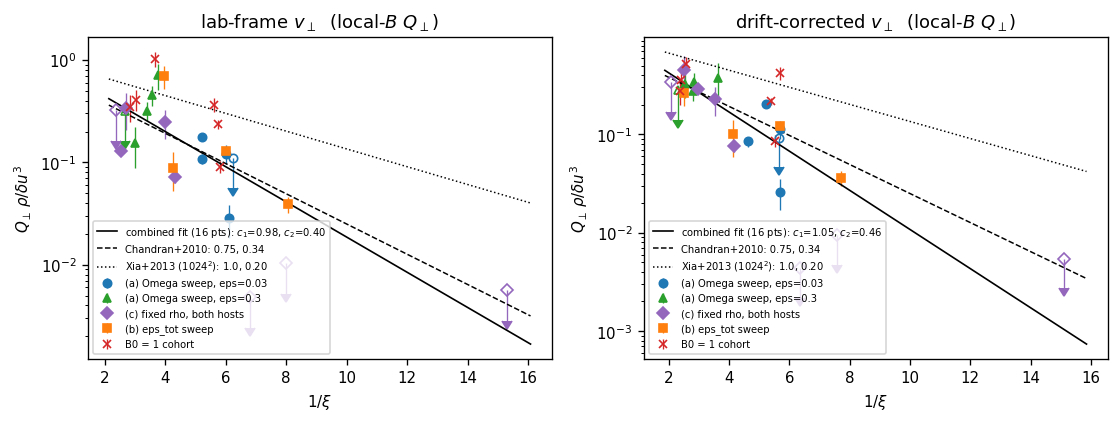

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(9.4, 3.6))
style = [("(a) Omega sweep, eps=%g" % R.A_HOSTS[0], "o", "C0"),
         ("(a) Omega sweep, eps=%g" % R.A_HOSTS[1], "^", "C2"),
         ("(c) fixed rho, both hosts", "D", "C4"),
         ("(b) eps_tot sweep", "s", "C1"),
         ("B0 = 1 cohort", "x", "C3")]
for name, m, c in style:
    p = sets[name]
    for j, tag in enumerate(TAGS):
        xk, rk, dk = TAGS[tag]
        scale = p[rk]/p[dk]**3
        # a point whose Q is not 2 sigma above zero is plotted as an upper limit (and is
        # held out of the fit); where Q is negative beyond that, the limit is the 2 sigma
        # noise level itself
        lim = p["Q"] <= 2*p["Qerr"]
        qup = np.maximum(p["Q"] + 2*p["Qerr"], 2*p["Qerr"])*scale
        ax[j].errorbar(1.0/p[xk][~lim], (p["Q"]*scale)[~lim], yerr=(p["Qerr"]*scale)[~lim],
                       fmt=m, color=c, ms=5, lw=0.8, label=name)
        if lim.any():
            ax[j].errorbar(1.0/p[xk][lim], qup[lim], yerr=0.5*qup[lim], uplims=True,
                           fmt=m, color=c, ms=5, mfc="none", lw=0.8)
for j, tag in enumerate(TAGS):
    fr = fits[("(a)+(b)+(c) combined", tag)]
    c1, c2, info = fr["c1"], fr["c2"], fr["info"]
    xs = np.linspace(0.9*min(info["x"]), 1.05*max(info["x"]), 50)
    ax[j].plot(xs, c1*np.exp(-c2*xs), "k-", lw=1.0,
               label=f"combined fit ({fr['n']} pts): $c_1$={c1:.2f}, $c_2$={c2:.2f}")
    ax[j].plot(xs, 0.75*np.exp(-0.34*xs), "k--", lw=0.9, label="Chandran+2010: 0.75, 0.34")
    ax[j].plot(xs, 1.0*np.exp(-0.20*xs), "k:", lw=0.9, label="Xia+2013 (1024$^2$): 1.0, 0.20")
    ax[j].set_yscale("log"); ax[j].set_xlabel(r"$1/\xi$")
    ax[j].set_ylabel(r"$Q_\perp\,\rho/\delta u^3$")
    ax[j].set_title(("lab-frame " if tag == "lab" else "drift-corrected ") + r"$v_\perp$"
                    + r"  (local-$B$ $Q_\perp$)")
    ax[j].legend(fontsize=6)
plt.tight_layout(); plt.show()

In [16]:
# What the suppressed points say. A window whose Q is not 2 sigma above zero is an upper
# limit Q_up = Q + 2 sigma (or 2 sigma itself where Q is negative); holding c1 at the
# combined fit's value, the exponential can only accommodate it if
# c2 >= xi*log(c1 du^3/(rho Q_up)).
print(f"combined exponential fit c1 = {c1c:.3f}, c2 = {c2c:.3f} (the {_cf['n']} measured "
      f"points); combined power law Q ~ du^{cpl[1]:.2f} rho^{cpl[2]:.2f} over the same "
      f"points. What each predicts at the points held out as limits:\n")
print(f"{'run':<44} {'xi':>6} {'Q + 2 sigma':>12} {'exp fit':>10} {'/limit':>7} "
      f"{'power law':>10} {'/limit':>7} {'c2 >=':>7}")
for name, p in sets.items():
    if name in ("(a) both hosts", "(c) fixed rho, both hosts", "(b)+(c), no design (a)",
                "(a)+(b)+(c) combined"):
        continue
    for j in np.where(p["Q"] <= 2*p["Qerr"])[0]:
        qup = max(p["Q"][j] + 2*p["Qerr"][j], 2*p["Qerr"][j])
        qfit = c1c*np.exp(-c2c/p["xi"][j])*p["du"][j]**3/p["rho"][j]
        qpl = np.exp(cpl[0] + cpl[1]*np.log(p["du"][j]) + cpl[2]*np.log(p["rho"][j]))
        bound = p["xi"][j]*np.log(c1c*p["du"][j]**3/(p["rho"][j]*qup))
        print(f"{name + ' | ' + p['label'][j]:<44} {p['xi'][j]:6.3f} {qup:12.3e} "
              f"{qfit:10.3e} {qfit/qup:7.2f} {qpl:10.3e} {qpl/qup:7.2f} {bound:7.2f}")
print("\nthe last column is the smallest c2 that would accommodate the limit at the fitted "
      "c1: a point below both curves is evidence for MORE suppression, not less. The two "
      "'/limit' columns are how far each model overshoots the limit it has to respect.")

combined exponential fit c1 = 0.976, c2 = 0.396 (the 16 measured points); combined power law Q ~ du^4.50 rho^-0.45 over the same points. What each predicts at the points held out as limits:

run                                              xi  Q + 2 sigma    exp fit  /limit  power law  /limit   c2 >=
(a) Omega sweep, eps=0.03 | (a) Omega = 15, B0 = 10  0.160    1.709e-02  1.265e-02    0.74  1.012e-02    0.59    0.35
(a) Omega sweep, eps=0.3 | (a) Omega = 5, B0 = 10  0.372    3.808e-01  4.007e-01    1.05  9.583e-01    2.52    0.41
(c) fixed rho, eps=0.03 | (c) ring v_perp = 2, Omega = 20.4  0.125    1.783e-03  6.998e-03    3.93  1.140e-02    6.40    0.57
(c) fixed rho, eps=0.03 | (c) ring v_perp = 4, Omega = 40.7  0.065    1.037e-03  4.205e-04    0.41  1.249e-02   12.05    0.34
(c) fixed rho, eps=0.3 | (c) ring v_perp = 0.5, Omega = 5.1  0.421    4.404e-01  5.197e-01    1.18  1.017e+00    2.31    0.47
(c) fixed rho, eps=0.3 | (c) ring v_perp = 4, Omega = 40.7  0.147    1.066e-02  1.439e

In [17]:
# the frame effect: local-B against zhat-referred rates over the SAME windows
print(f"{'run':<40} {'Q_perp(B)':>10} {'Q_perp(z)':>10} {'ratio':>7}   "
      f"{'Q_par(B)':>10} {'Q_z(z)':>10} {'Qpar/Qperp (B)':>15}")
for name in ("(a) both hosts", "(c) fixed rho, both hosts", "(b) eps_tot sweep",
             "B0 = 1 cohort"):
    p = sets[name]
    for j in range(len(p["e"])):
        star = "*" if p["Q"][j] <= 2*p["Qerr"][j] else " "
        print(f"{name + ' | ' + p['label'][j]:<40} {p['Q'][j]:10.3e}{star}{p['Qz'][j]:10.3e} "
              f"{p['Qz'][j]/p['Q'][j]:7.3f}   {p['Qpar'][j]:10.3e} {p['Qzz'][j]:10.3e} "
              f"{p['Qpar'][j]/p['Q'][j]:15.3f}")

def _frame_gap(names):
    g = []
    for nm in names:
        p = sets[nm]
        m = p["Q"] > 2*p["Qerr"]
        g.append(np.abs(p["Qz"][m]/p["Q"][m] - 1.0))
    return 100*float(np.max(np.concatenate(g)))

hi = _frame_gap(["(a) both hosts", "(c) fixed rho, both hosts", "(b) eps_tot sweep"])
lo = _frame_gap(["B0 = 1 cohort"])
print(f"\nover the MEASURED points only (limits starred above, and excluded here because a "
      f"ratio of two numbers consistent with zero is meaningless): the zhat-referred and "
      f"local-B rates agree to {hi:.1f}% at B0 = 10 "
      f"(delta_B/B0 = {np.sqrt(2*aem.mean())/R.B0_PROD:.2f} in the eps_tot = "
      f"{R.EPS_SHOW:g} host, less in the weaker ones) and to {lo:.0f}% at B0 = 1 "
      f"(delta_B/B0 = {np.sqrt(2*aem.mean())/R.B0_LOW:.1f}). The field direction tilts at "
      f"O(eps) and |B| only at O(eps^2), so this is where the ordering puts it.")
print("Q_par/Q_perp, the last column, is the quantity B0 does control: ~0.01-0.04 at "
      "B0 = 10 against ~0.5-1.3 at B0 = 1, at the same Omega, rho and xi.")

run                                       Q_perp(B)  Q_perp(z)   ratio     Q_par(B)     Q_z(z)  Qpar/Qperp (B)
(a) both hosts | (a) Omega = 5, B0 = 10   1.441e-02  1.444e-02   1.001    2.342e-04  2.133e-04           0.016
(a) both hosts | (a) Omega = 7.5, B0 = 10  1.343e-02  1.349e-02   1.004    1.187e-04  6.455e-05           0.009
(a) both hosts | (a) Omega = 10, B0 = 10  1.306e-02  1.297e-02   0.993    2.308e-04  3.202e-04           0.018
(a) both hosts | (a) Omega = 15, B0 = 10  8.529e-03* 8.495e-03   0.996    3.596e-04  3.937e-04           0.042
(a) both hosts | (a) Omega = 20, B0 = 10  5.933e-03  5.911e-03   0.996    1.728e-04  1.948e-04           0.029
(a) both hosts | (a) Omega = 5, B0 = 10   1.647e-01* 1.641e-01   0.997    4.125e-03  4.690e-03           0.025
(a) both hosts | (a) Omega = 7.5, B0 = 10  1.992e-01  2.011e-01   1.009    8.676e-03  6.828e-03           0.044
(a) both hosts | (a) Omega = 10, B0 = 10  5.795e-01  5.652e-01   0.975    1.064e-02  2.497e-02           0.018

### Reading the fit

**The exponential is there, at roughly the published strength.** Under the notebook's own
exclusion rule — a rate that is not $2\sigma$ above zero is an upper limit and does not enter
the log-OLS — the three fitted designs give **16 measured points** (out of 22; the other six
are limits) spanning $\xi = 0.124$–$0.39$, a factor 3.2. The combined fit:

$$c_1 = 0.98\ (\times/\div1.8),\qquad c_2 = 0.396\pm0.128
  \qquad\text{(lab-frame }v_\perp,\ \text{local-}\mathbf{B}\ Q_\perp),$$
$$c_1 = 1.06\ (\times/\div1.5),\qquad c_2 = 0.458\pm0.086
  \qquad\text{(drift-corrected }v_\perp,\ \text{local-}\mathbf{B}\ Q_\perp),$$

against Chandran et al. (2010)'s $c_1\approx0.75$, $c_2\approx0.34$ and Xia et al. (2013)'s
$c_2 = 0.44$ at $128^3$ falling to $0.20$ at $1024^2\times256$, with $c_1\sim0.7$–$1.1$ at
$\beta_i = 0.006$. Our $\beta_i = 0.01$, and $c_1\approx1$ sits in their low-$\beta$ range.

Two $R^2$ values are printed for every fit and they are **not** interchangeable.
$R^2(\mathrm{norm}) = 0.40$ is the fit's own, on $\log(Q_\perp\rho/\delta u^3)$ — the
quantity the two-parameter line is fitted to, with the $\delta u^3/\rho$ scaling already
divided out, so it scores only the exponential factor. $R^2(\log Q) = 0.88$ is on
$\log Q_\perp$ itself, which is what the power-law comparison below is scored on and which
credits the model for the prefactor as well.

**How much of that is the protocol?** The sensitivity table under the fits, all on the
combined set (local-$\mathbf B$ $Q_\perp$ and lab $v_\perp$ unless the row says otherwise):

| choice | $c_2$ | $n$ |
| --- | --- | --- |
| **headline**, $2\sigma$ rule | $\mathbf{0.396\pm0.128}$ | 16 |
| drift-corrected $v_\perp$ | $0.458\pm0.086$ | 16 |
| $Q_\perp$ referred to $\hat z$, same points | $0.395\pm0.128$ | 16 |
| every point with a logarithm (limits let in) | $0.317\pm0.114$ | 19 |
| $\hat z$-referred $Q_\perp$, no limit handling at all | $0.593\pm0.071$ | 20 |
| without design (a) | $0.311\pm0.165$ | 8 |
| design (a) alone | $0.579\pm0.227$ | 8 |
| design (b) alone, drift-corrected | $0.342\pm0.099$ | 4 |
| $B_0 = 1$ cohort, same protocol | $0.331\pm0.222$ | 6 |

The **frame** is worth $0.001$ in $c_2$ at $\delta B/B_0 = 0.18$ — at this amplitude it is
not the lever. The **drift correction** is worth $+0.06$. **How the sub-$2\sigma$ points are
handled** is worth $-0.08$ (letting them in as if they were measurements) to $+0.20$ (the
$\hat z$ fit with no limit handling at all, which admits four points whose local-$\mathbf B$
rate is not positive, including the $\xi = 0.065$ ring whose rate changes sign between
frames). That last row is the reason the rule exists, and it is the largest single entry in
the table. Which **designs** are included is worth as much again ($0.31$ to $0.58$). So the
number to carry away is $c_2\approx0.4$ with a systematic spread of $\pm0.15$ on top of the
$\pm0.13$ fit error, not a three-digit measurement.

Not every design carries the same weight, and the reason is the **lever arm in $\xi$**:

- **(b), the forcing-amplitude sweep**, has the longest one ($\times30$ in
  $\varepsilon_{tot}$, $\times3.1$ in $\xi$) and gives $c_2 = 0.342\pm0.099$ with
  $R^2(\mathrm{norm}) = 0.86$ in the drift-corrected frame — on its own, and by itself the
  cleanest single number here. All four of its points are measurements.
- **(c), Xia's fixed-$\rho$ design**, was meant to have the strongest lever but delivers
  four measurements and four limits: at $\varepsilon_{tot} = 0.03$ the $v_\perp = 2$ and $4$
  rings show *no* heating over 60 time units ($\langle v_{\perp B}^2\rangle$ flat to
  $-1\%$/$-0\%$), and so does the $v_\perp = 4$ ring at $\varepsilon_{tot} = 0.3$ ($-3\%$) —
  which is what an exponential predicts. Its four measured points give $c_2 = 0.34\pm0.49$
  (lab) or $1.02\pm0.21$ (drift-corrected), i.e. nothing on their own; the *limits* are its
  contribution, and they are the strongest constraint in the dataset (below).
- **(a), the $\Omega$ sweep**, has the shortest lever ($\times2.0$ in $\xi$ over both hosts)
  because the spectrum is shallow ($E_u\propto k^{-1.36}$, so $\delta u\propto\rho^{0.18}$)
  and $v_\perp$ is pinned by the $\mathbf E\times\mathbf B$ pickup. Its two hosts disagree:
  $c_2 = +1.09\pm0.85$ at $\varepsilon_{tot} = 0.03$ and $c_2 = -2.01\pm0.08$ at $0.3$, the
  latter with $R^2(\mathrm{norm}) = 0.997$. **That is a real tension, not just noise.** A
  negative $c_2$ says $Q_\perp$ grows *faster* than $\delta u^3/\rho$ as $\rho$ shrinks at
  fixed turbulence, and the printed $\rho$-scalings say the same thing directly: the
  normalization predicts $Q_\perp\propto\rho^{-0.46}$ (from $\delta u\propto\rho^{0.18}$),
  the $\varepsilon_{tot} = 0.3$ host measures $\rho^{-1.08}$ and the
  $\varepsilon_{tot} = 0.03$ host measures $\rho^{+0.67}$. Design (a) alone cannot constrain
  $c_2$ — its $\xi$ lever is too short to separate the exponential from the prefactor — but
  the fact that the two hosts bracket the assumed $\rho$ scaling from both sides, one of them
  tightly, is a statement about the normalization and not about $c_2$.

**Is the exponential necessary?** Scored on the same quantity ($\log Q_\perp$ over the 16
measured points), the two-parameter exponential reaches $R^2 = 0.876$ and the
three-parameter power law $Q_\perp\propto\delta u^n\rho^m$ reaches $0.922$ with $n = 4.5$,
$m = -0.45$. So this dataset does not *discriminate* on the measured points — and note that
the free $m$ is half the $-1$ the Chandran normalization assumes, with $\delta u$ and $\rho$
strongly correlated across the sample, so neither exponent is independently determined. The
**upper limits** are what separates the models: extrapolated to the suppressed rings, the
power law overshoots them by factors of $6.4$, $12$ and $49$, the exponential by $3.9$,
$0.4$ and $13.5$. Both overshoot the worst one. Held at the fitted $c_1$, those three limits
require $c_2\ge0.34$ ($\xi = 0.065$), $\ge0.57$ ($\xi = 0.125$) and $\ge0.78$
($\xi = 0.147$) — i.e. the suppressed points want *more* suppression than the fitted
$0.40$, not less.

**Against the first pass.** The A3 version of this notebook — $B_0 = 1$, $\hat z$ frame, no
projection, Laplacian dissipation, and rate windows spanning the whole particle run with no
upper-limit handling — found no exponential at all ($c_2 = 0.02\pm0.02$; its amplitude sweep
alone gave $0.12\pm0.04$). **The amplitude by itself does not explain that.** Measured under
the *present* protocol, this run's $B_0 = 1$ cohort gives $c_2 = 0.331\pm0.222$ (lab
$v_\perp$, local-$\mathbf B$ $Q_\perp$) — consistent with the production cohort's
$0.396\pm0.128$ and with Chandran's $0.34$. Two of the other three changes are measured here
to be small as well: the frame is worth $0.001$ in $c_2$, and the projection $1.2\sigma$ in
energization (next section). What is left is (i) the **measurement protocol** — the short
window starting after the $\mathbf E\times\mathbf B$ pickup, which at
$u_{rms}\approx v_{th}$ is an $O(1)$ contribution to $\langle v_\perp^2\rangle$, and the
upper-limit rule, worth up to $+0.20$ in $c_2$ here — and (ii) the **base turbulence**,
`hyper=3` here against `hyper=1` there, which changes $\delta u(\rho)$ at every $\rho$ the
particles sample. This notebook cannot separate (i) from (ii): no ensemble here was measured
under the old protocol, and no run here uses the old dissipation. This is a corrected
measurement, not a diagnosis of the first pass. What $B_0$ *does* demonstrably control is the
parallel/perpendicular split, which is the next section.

## Headline 2 — the parallel channel

Three comparisons, all in the $\varepsilon_{tot} = 0.3$ design-(a) run:

1. **projected vs unprojected** ideal ensembles at $\Omega = 10$, $B_0 = 10$: identical in
   every respect except that one sees $\tilde{\mathbf E}$ and the other the raw
   $\bar{\mathbf E}$. The difference is the numerical $E_\parallel$ energization.
2. the **full-$\partial\psi/\partial t$** ensemble's exact 2D invariant
   $p_z = v_z - (q/m)\psi$, against the projected ideal ensemble's. The projected one is
   *not* expected to conserve $p_z$: projection changes $E_z$ (it subtracts
   $(\bar{\mathbf E}\cdot\bar{\mathbf B})B_z/|B|^2$ from it), so the exact cancellation
   behind the invariant no longer applies. Its drift is not an error — it is the size of what
   the projection removed, seen a second way.
3. the $B_0 = 1$ vs $B_0 = 10$ **twins**: the same $\Omega$, $\rho$ and $\xi$, but
   $\delta B/B_0 = 1$ against $0.1$. The split between parallel and perpendicular
   energization ($\dot v_{\parallel B}^2$ vs $\dot v_{\perp B}^2$, `w_ez_ideal` vs
   `w_eperp`) is the direct test of the first pass's "the parallel channel dominates" claim,
   which was made at $B_0 = 1$.

The resistive piece of $E_z$ is hyper-resistive here ($-\nu k^6$), so it is *not* a physics
quantity; the full-mask ensemble exists only for the $\partial\psi/\partial t$-exactness
check.

sampled E.B at the 4096 unprojected particles at t = 50.1: rms(E.B)/rms(|E||B|) = 1.55e-03 -- zero on the collocation grid, so this is the interpolation's own E_parallel, and it is what epar_project removes.

projection contrast at Omega = 10, B0 = 10, over t = 20.1 -> 50.1   (+- is the ensemble mean's standard error over 4096 particles)

                                        d<KE>                w_eperp             w_ez_ideal  w_ez/w_tot
projected                  5.4918e+00+-7.6e-02     5.0505e+00+-9.3e-02     4.4124e-01+-6.0e-02       0.080
unprojected                5.6162e+00+-7.6e-02     5.2353e+00+-9.1e-02     3.8090e-01+-5.7e-02       0.068

numerical E_parallel energization = (unprojected - projected) d<KE> = +1.2440e-01 +- 1.1e-01 (+1.2 sigma), i.e. +2.3% of the projected ensemble's energy gain
  in the E_z column alone: -6.0344e-02 +- 8.2e-02 (-0.7 sigma), -13.7% of the projected E_z work
the two ensembles are independent RNG draws of the same distribution (there is no per

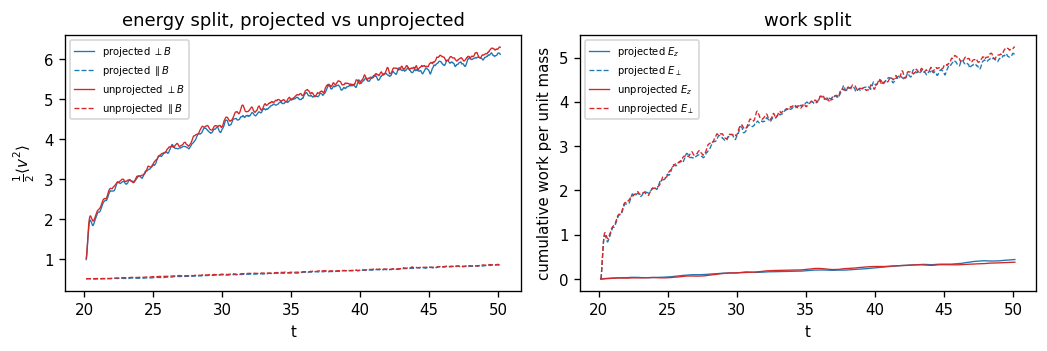

In [18]:
ip, iu, ifu = idx_a["ideal_ref"], idx_a["unprojected"], idx_a["full"]
IEP, IEZ = WORK_PIECES.index("eperp"), WORK_PIECES.index("ez_ideal")

def _sem(a):
    '''standard error of a per-particle ensemble mean, (n_ens,) -- the resolution of any
    comparison BETWEEN ensembles, which are independent RNG draws.'''
    a = np.asarray(a, dtype=np.float64)
    return np.std(a, axis=1, ddof=1)/np.sqrt(a.shape[1])

dke_p = 0.5*(np.sum(np.asarray(p_last.v)**2, axis=2) - np.sum(np.asarray(p_first.v)**2, axis=2))
sem_dke = _sem(dke_p)
sem_w = np.stack([_sem(np.asarray(p_last.w)[:, :, i] - np.asarray(p_first.w)[:, :, i])
                  for i in range(len(WORK_PIECES))], axis=1)

# the numerical E_parallel the projection removes, measured directly at the particles: the
# collocation-grid ideal fields satisfy E.B = 0 exactly, but E and B are interpolated
# independently, so the SAMPLED product is not zero
_pf = particle_fields(load_state(path_a, asteps[-1], params_a), kgrid, params_a)
_ens = params_a.particles["ensembles"][iu]
_E, _B = assemble(_pf, _ens["mask"], _ens["B0"])
_Ep = np.asarray(interp.gather(_E, p_last.x[iu], params_a), dtype=np.float64)
_Bp = np.asarray(interp.gather(_B, p_last.x[iu], params_a), dtype=np.float64)
_eb = np.sum(_Ep*_Bp, axis=1)
_scale = np.linalg.norm(_Ep, axis=1)*np.linalg.norm(_Bp, axis=1)
print(f"sampled E.B at the {R.NPART} unprojected particles at t = {ats[-1]:.1f}: "
      f"rms(E.B)/rms(|E||B|) = "
      f"{np.sqrt(np.mean(_eb**2))/np.sqrt(np.mean(_scale**2)):.2e} -- zero on the "
      f"collocation grid, so this is the interpolation's own E_parallel, and it is what "
      f"epar_project removes.\n")

print(f"projection contrast at Omega = {R.OM_REF:g}, B0 = {R.B0_PROD:g}, over "
      f"t = {ats[0]:.1f} -> {ats[-1]:.1f}   (+- is the ensemble mean's standard error over "
      f"{R.NPART} particles)\n")
print(f"{'':<22} {'d<KE>':>22} {'w_eperp':>22} {'w_ez_ideal':>22} {'w_ez/w_tot':>11}")
for name, e in (("projected", ip), ("unprojected", iu)):
    print(f"{name:<22} {bud['dke'][e]:14.4e}+-{sem_dke[e]:7.1e} "
          f"{bud['work'][e][IEP]:14.4e}+-{sem_w[e, IEP]:7.1e} "
          f"{bud['work'][e][IEZ]:14.4e}+-{sem_w[e, IEZ]:7.1e} "
          f"{bud['work'][e][IEZ]/bud['total_work'][e]:11.3f}")
dke_num = bud["dke"][iu] - bud["dke"][ip]
sig = np.hypot(sem_dke[iu], sem_dke[ip])
dez = bud["work"][iu][IEZ] - bud["work"][ip][IEZ]
sig_ez = np.hypot(sem_w[iu, IEZ], sem_w[ip, IEZ])
print(f"\nnumerical E_parallel energization = (unprojected - projected) d<KE> = "
      f"{dke_num:+.4e} +- {sig:.1e} ({dke_num/sig:+.1f} sigma), i.e. "
      f"{dke_num/bud['dke'][ip]*100:+.1f}% of the projected ensemble's energy gain")
print(f"  in the E_z column alone: {dez:+.4e} +- {sig_ez:.1e} ({dez/sig_ez:+.1f} sigma), "
      f"{(bud['work'][iu][IEZ]/bud['work'][ip][IEZ] - 1)*100:+.1f}% of the projected E_z work")
print("the two ensembles are independent RNG draws of the same distribution (there is no "
      "per-particle pairing), so the standard errors above are the resolution of this "
      "comparison.")

fig, ax = plt.subplots(1, 2, figsize=(8.8, 3.0))
for e, c, nm in ((ip, "C0", "projected"), (iu, "C3", "unprojected")):
    ax[0].plot(mom_a["t"], 0.5*mom_a["vperpB2"][:, e], color=c, lw=0.8, label=nm+r" $\perp B$")
    ax[0].plot(mom_a["t"], 0.5*mom_a["vparB2"][:, e], color=c, lw=0.8, ls="--",
               label=nm+r" $\parallel B$")
    ax[1].plot(mom_a["t"], mom_a["w_ez_ideal"][:, e], color=c, lw=0.8, label=nm+" $E_z$")
    ax[1].plot(mom_a["t"], mom_a["w_eperp"][:, e], color=c, lw=0.8, ls="--",
               label=nm+r" $E_\perp$")
for a, ylab in zip(ax, (r"$\frac{1}{2}\langle v^2\rangle$", "cumulative work per unit mass")):
    a.set_xlabel("t"); a.set_ylabel(ylab); a.legend(fontsize=6)
ax[0].set_title("energy split, projected vs unprojected")
ax[1].set_title("work split")
plt.tight_layout(); plt.show()

In [19]:
def pz(pstate, state, params):
    psi = grids.ifft(state.fields[1], params)[None]
    return np.stack([np.asarray(pstate.v[e][:, 2]
                                - ens["qm"]*interp.gather(psi, pstate.x[e], params)[:, 0])
                     for e, ens in enumerate(params.particles["ensembles"])])

pz0 = pz(p_first, load_state(path_a, asteps[0], params_a), params_a)
pz1 = pz(p_last, load_state(path_a, asteps[-1], params_a), params_a)
psi_rms = float(np.sqrt(np.mean(np.asarray(
    grids.ifft(load_state(path_a, asteps[0], params_a).fields[1], params_a))**2)))
qm_ref = R.OM_REF/R.B0_PROD
print(f"gate-4 invariant p_z = v_z - (q/m) psi, t = {ats[0]:.1f} -> {ats[-1]:.1f}   "
      f"(scale (q/m)*rms(psi) = {qm_ref*psi_rms:.4f}, psi_rms = {psi_rms:.3f})")
for name, e in (("full dpsi/dt", ifu), ("projected ideal", ip), ("unprojected ideal", iu)):
    d = pz1[e] - pz0[e]
    dv = np.asarray(p_last.v[e][:, 2]) - np.asarray(p_first.v[e][:, 2])
    print(f"  {name:<18} rms |dp_z| = {np.sqrt(np.mean(d**2)):9.5f}  "
          f"({np.sqrt(np.mean(d**2))/(qm_ref*psi_rms):7.3f} of the scale);  "
          f"rms dv_z = {np.sqrt(np.mean(dv**2)):.4f}")
print("\nonly the full-mask ensemble is expected to conserve p_z: its E_z is the exact "
      "dpsi/dt the discrete psi obeys. Its residual is the pipeline's discretization error "
      "(fields frozen across a step, bilinear gather). The projected ensemble's drift is "
      "the acceleration its mask omits PLUS what the projection subtracts from E_z.")

gate-4 invariant p_z = v_z - (q/m) psi, t = 20.1 -> 50.1   (scale (q/m)*rms(psi) = 1.3179, psi_rms = 1.318)
  full dpsi/dt       rms |dp_z| =   0.00684  (  0.005 of the scale);  rms dv_z = 1.5236
  projected ideal    rms |dp_z| =   1.58477  (  1.203 of the scale);  rms dv_z = 0.9709
  unprojected ideal  rms |dp_z| =   1.55124  (  1.177 of the scale);  rms dv_z = 0.9566

only the full-mask ensemble is expected to conserve p_z: its E_z is the exact dpsi/dt the discrete psi obeys. Its residual is the pipeline's discretization error (fields frozen across a step, bilinear gather). The projected ensemble's drift is the acceleration its mask omits PLUS what the projection subtracts from E_z.


B0 = 1 against B0 = 10 at the same Omega (same rho, same xi), eps_tot = 0.3, over t = 20.1 -> 50.1

 Omega   B0       d<KE>     w_eperp  w_ez_ideal  w_ez/w_tot   Q_perp(B)    Q_par(B)  Qpar/Qperp psi_rms/B0.rho
   5.0   10  4.8208e+00  4.6565e+00  1.6430e-01       0.034   1.647e-01   4.125e-03       0.025           0.31
   5.0    1  1.9715e+01  2.2082e+00  1.7506e+01       0.888   3.813e-01   2.317e-01       0.608           2.96

  10.0   10  5.4918e+00  5.0505e+00  4.4124e-01       0.080   5.795e-01   1.064e-02       0.018           0.63
  10.0    1  3.2023e+01  2.2781e+00  2.9745e+01       0.929   8.873e-01   4.137e-01       0.466           6.34

  20.0   10  5.8942e+00  5.0423e+00  8.5191e-01       0.145   6.785e-01   1.346e-02       0.020           1.28
  20.0    1  4.9102e+01  2.3893e+00  4.6713e+01       0.951   1.027e+00   5.516e-01       0.537          14.06



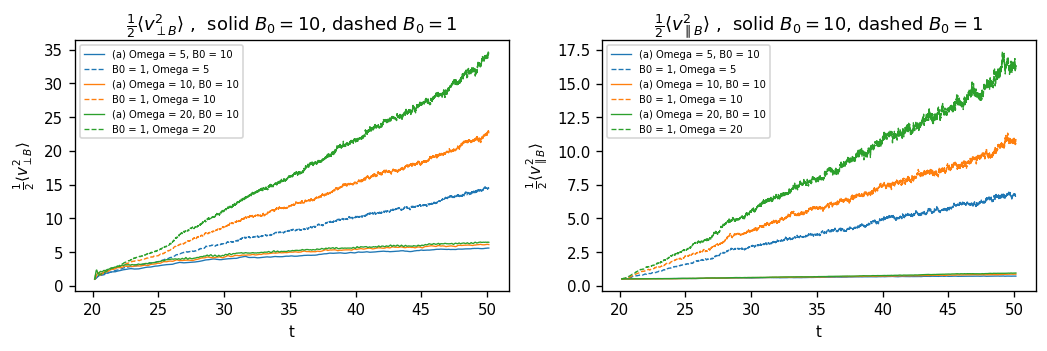

In [20]:
tw = R.A_TWIN
print(f"B0 = 1 against B0 = {R.B0_PROD:g} at the same Omega (same rho, same xi), "
      f"eps_tot = {R.EPS_SHOW:g}, over t = {ats[0]:.1f} -> {ats[-1]:.1f}\n")
print(f"{'Omega':>6} {'B0':>4} {'d<KE>':>11} {'w_eperp':>11} {'w_ez_ideal':>11} "
      f"{'w_ez/w_tot':>11} {'Q_perp(B)':>11} {'Q_par(B)':>11} {'Qpar/Qperp':>11} "
      f"{'psi_rms/B0.rho':>14}")
qa, ql = pts_a[R.EPS_SHOW], pts_low[R.EPS_SHOW]
for jl, el in enumerate(idx_a["lowB0"]):
    ea = tw[el]
    ja = int(np.where(qa["e"] == ea)[0][0])
    for tag, e, pp, jj in ((R.B0_PROD, ea, qa, ja), (R.B0_LOW, el, ql, jl)):
        # the canonical parallel excursion over the perpendicular speed,
        # (q/m) psi_rms / v_perp = psi_rms/(B0 rho): the amplitude enters through 1/B0
        print(f"{pp['om'][jj]:6.1f} {tag:4g} {bud['dke'][e]:11.4e} "
              f"{bud['work'][e][IEP]:11.4e} {bud['work'][e][IEZ]:11.4e} "
              f"{bud['work'][e][IEZ]/bud['total_work'][e]:11.3f} {pp['Q'][jj]:11.3e} "
              f"{pp['Qpar'][jj]:11.3e} {pp['Qpar'][jj]/pp['Q'][jj]:11.3f} "
              f"{psi_rms/(tag*pp['rho'][jj]):14.2f}")
    print()

fig, ax = plt.subplots(1, 2, figsize=(8.8, 3.0))
for jl, el in enumerate(idx_a["lowB0"]):
    ea = tw[el]
    for e, c, ls in ((ea, "C%d" % jl, "-"), (el, "C%d" % jl, "--")):
        ax[0].plot(mom_a["t"], 0.5*mom_a["vperpB2"][:, e], color=c, ls=ls, lw=0.8,
                   label=labels_a[e])
        ax[1].plot(mom_a["t"], 0.5*mom_a["vparB2"][:, e], color=c, ls=ls, lw=0.8,
                   label=labels_a[e])
for a, ttl in zip(ax, (r"$\frac{1}{2}\langle v_{\perp B}^2\rangle$",
                       r"$\frac{1}{2}\langle v_{\parallel B}^2\rangle$")):
    a.set_xlabel("t"); a.set_ylabel(ttl); a.legend(fontsize=6); a.set_title(
        ttl + r" ,  solid $B_0=10$, dashed $B_0=1$")
plt.tight_layout(); plt.show()

### Where the parallel kicks come from

$E_z = -\{\varphi,\psi\}$ is a large-scale field, but $\psi$'s small-scale structure is
current sheets. The short high-cadence tail of the $\varepsilon_{tot}=0.3$ run (snapshots
every $\sim0.03$ time units instead of $1.2$, so a particle moves a few grid cells rather
than a box length between samples) lets $\Delta v_z$ be binned by the local $|j_z| =
|\nabla^2\psi|$ at the start of each interval. The **E = 0 control** is in the plot for a
reason: it feels no electric field, so whatever $|j_z|$ dependence *it* shows is the
$v\times b_\perp$ rotation and not acceleration.

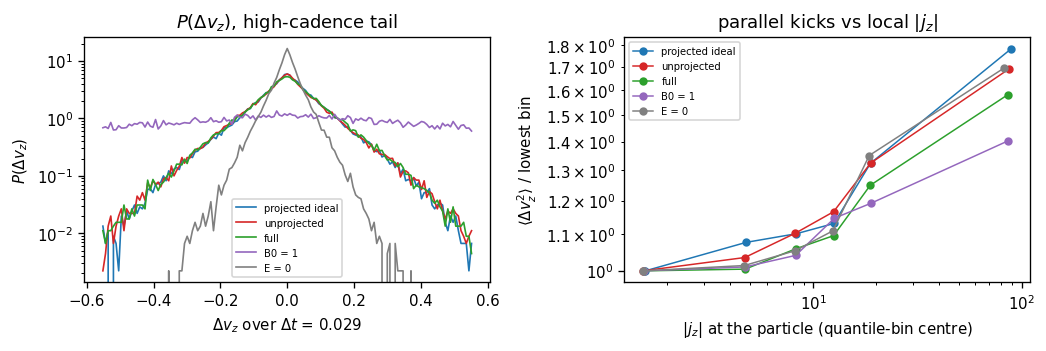

14 snapshot pairs, interval 0.0289, 57344 increments per ensemble
|j_z| quantile-bin centres: [ 1.6  4.8  8.3 12.6 18.9 89.5]

projected ideal    <dv_z^2> [0.0117  0.0126  0.01289 0.01324 0.01548 0.02087]  top/bottom bin  1.78
unprojected        <dv_z^2> [0.0125  0.01294 0.01379 0.01458 0.01655 0.02114]  top/bottom bin  1.69
full               <dv_z^2> [0.01313 0.01318 0.0139  0.01438 0.0164  0.02077]  top/bottom bin  1.58
B0 = 1             <dv_z^2> [4.0782  4.11989 4.24596 4.67722 4.86458 5.71999]  top/bottom bin  1.40
E = 0              <dv_z^2> [0.00201 0.00204 0.00212 0.00223 0.00271 0.00341]  top/bottom bin  1.70

absolute size vs shape: the projected ideal ensemble's <dv_z^2> is 5.8x the E = 0 control's in the lowest |j_z| bin and 6.1x in the highest, but its top/bottom RATIO (1.78) is the control's (1.70) to 5%: the |j_z| dependence is carried by the v x b_perp rotation, not by E_z.


In [21]:
fast = dirs["fast"]
fsteps, fts = snap_index(fast, params_a)
fps = [sn.load_particles(i, fast, params_a) for i in fsteps]
DVZ = np.concatenate([np.asarray(fps[j+1].v[:, :, 2]) - np.asarray(fps[j].v[:, :, 2])
                      for j in range(len(fsteps)-1)], axis=1)
JZ = np.concatenate([dpart.jz_at(fps[j], load_state(fast, fsteps[j], params_a), kgrid,
                                 params_a) for j in range(len(fsteps)-1)], axis=1)
cs = dpart.conditional_stats(DVZ, JZ, nq=6)
mid = 0.5*(cs["edges"][:, 1:] + cs["edges"][:, :-1])
SHOW = [(ip, "C0", "projected ideal"), (iu, "C3", "unprojected"), (ifu, "C2", "full"),
        (idx_a["lowB0"][1], "C4", "B0 = 1"), (idx_a["e_zero"], "grey", "E = 0")]

fig, ax = plt.subplots(1, 2, figsize=(8.8, 3.0))
lim = float(np.percentile(np.abs(DVZ[[ip, iu, ifu]]), 99.9))
edges, counts = dpart.increment_histogram(DVZ, bins=141, range=(-lim, lim))
ctr = 0.5*(edges[1:] + edges[:-1])
norm = counts/(counts.sum(axis=1, keepdims=True)*np.diff(edges))
for e, c, nm in SHOW:
    ax[0].semilogy(ctr, norm[e], color=c, lw=1.0, label=nm)
    ax[1].loglog(mid[e], cs["mean_sq"][e]/cs["mean_sq"][e][0], "o-", color=c, ms=4, lw=0.9,
                 label=nm)
ax[0].set_xlabel(r"$\Delta v_z$ over $\Delta t$ = %.3f" % float(np.mean(np.diff(fts))))
ax[0].set_ylabel(r"$P(\Delta v_z)$"); ax[0].legend(fontsize=6)
ax[0].set_title(r"$P(\Delta v_z)$, high-cadence tail")
ax[1].set_xlabel(r"$|j_z|$ at the particle (quantile-bin centre)")
ax[1].set_ylabel(r"$\langle\Delta v_z^2\rangle$ / lowest bin"); ax[1].legend(fontsize=6)
ax[1].set_title(r"parallel kicks vs local $|j_z|$")
plt.tight_layout(); plt.show()

print(f"{len(fsteps)-1} snapshot pairs, interval {float(np.mean(np.diff(fts))):.4f}, "
      f"{DVZ.shape[1]} increments per ensemble")
print(f"|j_z| quantile-bin centres: {np.array2string(mid[ip], precision=1)}\n")
for e, _c, nm in SHOW:
    m = cs["mean_sq"][e]
    print(f"{nm:<18} <dv_z^2> {np.array2string(m, precision=5)}  "
          f"top/bottom bin {m[-1]/m[0]:5.2f}")
_ms, _mz = cs["mean_sq"][ip], cs["mean_sq"][idx_a["e_zero"]]
print(f"\nabsolute size vs shape: the projected ideal ensemble's <dv_z^2> is "
      f"{_ms[0]/_mz[0]:.1f}x the E = 0 control's in the lowest |j_z| bin and "
      f"{_ms[-1]/_mz[-1]:.1f}x in the highest, but its top/bottom RATIO ({_ms[-1]/_ms[0]:.2f}) "
      f"is the control's ({_mz[-1]/_mz[0]:.2f}) to "
      f"{100*abs((_ms[-1]/_ms[0])/(_mz[-1]/_mz[0]) - 1):.0f}%: the |j_z| dependence is "
      f"carried by the v x b_perp rotation, not by E_z.")

### Reading the parallel channel

**The numerical $E_\parallel$ is not resolvable here.** The projected and unprojected
$\Omega = 10$ ensembles differ by $+2.3\%$ in total energization, which is $1.2\sigma$ of the
4096-particle sampling error, and by $-14\%$ ($0.7\sigma$) in the $E_z$ work column. The
projection removes a sampled $\bar{\mathbf E}\cdot\bar{\mathbf B}$ measured above at
$1.6\times10^{-3}$ of $|E||B|$, and at $B_0 = 10$ the $E_z$ channel it contaminates carries
only 8% of the work — so the energetic effect is small, and the two ensembles are independent
RNG draws rather than a particle-paired pair. What can be said is a bound: at this amplitude
the numerical $E_\parallel$ contributes no more than a few percent of the energization.
(A per-particle paired init would sharpen this by orders of magnitude and costs nothing;
it is open item (i) in `plans/TESTPART_PLAN.md` §5.)

**$p_z$ behaves exactly as the mask says it should.** The full-$\partial\psi/\partial t$
ensemble conserves $p_z = v_z - (q/m)\psi$ to $0.5\%$ of its $(q/m)\psi_{rms}$ scale over 30
time units — the residual is the pipeline's time discretization (fields frozen across a
step) — while the ideal ensembles drift by $120\%$ of the scale. The projected ensemble is
*not* expected to conserve it: projection subtracts $(\bar{\mathbf E}\cdot\bar{\mathbf B})
B_z/|B|^2$ from $E_z$, so the exact cancellation behind the invariant no longer holds. Its
drift is the same size as the unprojected one's ($1.20$ vs $1.18$), which is another way of
seeing that the projection is a small correction to a channel that is already dominated by
the omitted resistive and forcing pieces.

**The amplitude, not 2D, is what makes the parallel channel dominate.** At $B_0 = 1$ the
$E_z$ work is 89–95% of the total and $Q_\parallel/Q_\perp = 0.47$–$0.62$ (and $1.35$ for the
weakly-heated $\Omega = 20$ point at $\varepsilon_{tot} = 0.03$); at $B_0 = 10$, same
$\Omega$, same $\rho$, same $\xi$, same fields, it is 3–15% and $0.018$–$0.025$. The A3
notebook concluded that 2D *structurally* forces the parallel channel to dominate, from the
ratio of the canonical parallel excursion to the perpendicular speed, $\psi_{rms}/\rho\gg1$.
The correct ratio carries the amplitude:

$$\frac{(q/m)\,\psi_{rms}}{v_\perp} = \frac{\Omega\,\psi_{rms}}{B_0\,v_\perp}
  = \frac{\psi_{rms}}{B_0\,\rho},$$

which is $0.6$ at $B_0 = 10$ and $6.3$ at $B_0 = 1$ for the same orbit. The missing $1/B_0$
*is* $\varepsilon$: at $\delta B/B_0\sim1$ the parallel channel dominates, and at the
amplitude RMHD is actually derived for it does not. That disposes of the first pass's
"2D cannot make the parallel channel subdominant" argument — but **not** of its null result
for $c_2$, which the $B_0 = 1$ cohort reproduces at $c_2 = 0.33\pm0.22$ under this protocol
(see "Against the first pass" above).

**The $|j_z|$ correlation is not an $E_z$ effect.** $\langle\Delta v_z^2\rangle$ does rise
monotonically across the six $|j_z|$ quantiles — by $1.6$–$1.8$ from the lowest to the highest
bin in every ensemble that sees $E_z$ — but the **E = 0 control rises by $1.70$ as well**,
and it has no electric field at all: its only source of $\Delta v_z$ is the $v\times
b_\perp$ rotation. The ideal ensembles' kicks are $6\times$ larger in absolute terms, but
their top/bottom ratio is the control's to 5%. So this conditioning locates small-scale field
structure, not parallel acceleration; reading it as current-sheet acceleration would have
been a mistake, and the control is what says so. (The first pass reported the same statistic
as flat to $\le15\%$ at the production snapshot cadence, where a particle crosses hundreds of
cells per interval; at this cadence it is not flat, and it is still not a sheet signal.)

## What this does and does not show

**Does show.**

- **A stochastic-heating exponential in 2D RMHD at $\varepsilon = 0.1$**,
  $c_2 = 0.40\pm0.13$ (lab $v_\perp$) or $0.46\pm0.09$ (drift-corrected) with
  $c_1\approx1.0$, both in the local-$\mathbf B$ frame with the numerical $E_\parallel$
  projected out, from **16 measured points** over $\xi = 0.124$–$0.39$ with **six upper
  limits** held out of the fit. That brackets Chandran et al. (2010)'s $0.34$ and sits inside
  Xia et al. (2013)'s resolution-dependent $0.20$–$0.44$. The single cleanest design, the
  $\times30$ forcing-amplitude sweep, gives $0.34\pm0.10$ (drift-corrected) on its own. The
  systematic spread across the sensitivity table ($0.31$–$0.58$, dominated by which designs
  are in and how sub-$2\sigma$ rates are treated) is wider than the fit error.
- **That the parallel/perpendicular split is set by the amplitude, not by 2D.** $B_0$ is
  $1/\varepsilon$, not a unit; at $B_0 = 1$ the parallel channel carries 89–95% of the work
  and at $B_0 = 10$ it carries 3–15%, for the same $\Omega$, $\rho$, $\xi$ and fields. The
  controlling ratio is $\psi_{rms}/(B_0\rho)$, and the first pass's version of it was missing
  the $1/B_0$.
- **That the machinery is exact where it claims to be.** The per-piece work accumulators
  close against $\tfrac12|v|^2$ to $8\times10^{-14}$ ($4\times10^{-14}$ of the initial kinetic
  energy) across the 14 ensembles that do work, and a piece an ensemble's mask omits is
  *bitwise* zero (the two control ensembles do no work at all, so their closure ratio is
  $0/0$ and is printed as n/a). Both controls conserve $|v|^2$ per particle to
  $\sim6\times10^{-14}$ against energy gains of order 5–50, so nothing here is floor-limited.
  Snapshot-cadence `mu_of` reproduces the per-step sidecar $\mu$ to $3\times10^{-4}$. The
  gate-4 invariant holds to $0.5\%$ of its scale in a live production run for the full-mask
  ensemble and fails by $120\%$ for the ideal ones — the two facts that make the mask a
  measurement rather than a knob.
- **That the local-$\mathbf B$ frame matters exactly where the ordering says it should**:
  over the measured points $Q_\perp$ about $\hat z$ and about the local $\mathbf B$ agree to
  $\le2.5\%$ at $\delta B/B_0 = 0.18$ and differ by up to 16% at $\delta B/B_0 = 1.8$.

**Does not show.**

- **That the exponential is *required*.** Scored on the same 16 points, a three-parameter
  power law $Q_\perp\propto\delta u^{4.5}\rho^{-0.45}$ fits better than the two-parameter
  exponential ($R^2(\log Q) = 0.922$ vs $0.876$), and its $\rho$ exponent is half the $-1$
  the Chandran normalization assumes. The upper limits favour the exponential — the power law
  overshoots the suppressed rings by $6$–$49\times$ against the exponential's
  $0.4$–$13.5\times$ — but they are limits, not measurements, and both models overshoot the
  most suppressed ring. Separating the two needs points at $\xi\lesssim0.1$ with enough
  integration time to measure a small positive $Q_\perp$, which is a longer run than this one.
- **Why the first pass found no exponential.** The amplitude alone does not account for it:
  the $B_0 = 1$ cohort measured under this protocol gives $c_2 = 0.33\pm0.22$. The frame
  ($0.001$ in $c_2$) and the projection ($1.2\sigma$) are also too small. What is left is the
  measurement protocol (window placement plus upper-limit handling, worth up to $+0.20$ here)
  and the different base turbulence (`hyper=3` against `hyper=1`), and nothing in this
  notebook separates those two.
- **Anything about 3D.** 2D has no parallel decorrelation: $z$ is ignorable, $p_z$ is an
  exact invariant of the full-mask dynamics, and the $\varphi$ and $\psi$ structures a
  particle samples are frozen along $\hat z$. That the numbers land near the 3D published
  values is worth recording, not over-reading; Phase B is the measurement.
- **A converged inertial range.** $-\nu k^6$ at $\nu = 10^{-10}$ gives $E_u$ falling 4.0
  decades from its peak to the 2/3 cutoff with the dissipation range starting at $k\approx29$,
  and the power-law stretch the particles sample ($k_\rho = 3.5$–$14$ at insertion) is under a
  decade wide and shallow ($k^{-1.36}$). Xia et al. used Laplacian viscosity at
  $Re\le3.8\times10^4$; this is a synthetic inertial range, and the fitted $\delta u$ exponent
  inherits that.
- **A resolved numerical $E_\parallel$ measurement.** The projected/unprojected difference is
  $1.2\sigma$ with independent 4096-particle draws; only a per-particle paired init would
  turn it into a number.
- **Current-sheet acceleration.** The $|j_z|$-conditioned $\langle\Delta v_z^2\rangle$ rises
  by $1.6$–$1.8$ across the quantiles, but so does the E = 0 control's, so the trend belongs
  to the $v\times b_\perp$ rotation finding small-scale structure, not to $E_z$.
- **A transport coefficient for $\mu$.** The sidecar $\tfrac12\,d\,\mathrm{Var}(\mu)/dt$ and
  the snapshot-pair estimator differ by 9–41$\times$ because the pair interval is only about
  two gyroperiods; the E = 0 control, whose $\mu$ cannot diffuse, shows the same gap.
- **$\eta$-independence, or anything about the resistive channel.** With hyper-resistivity the
  $E_z$ resistive piece is not a physical field; it exists here only so the full-mask
  ensemble reproduces $\partial\psi/\partial t$ exactly.